# Propensity Score and Other Matching Methods

In [1]:
import os
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [2]:
os.getcwd()

'/mnt/nfs/CX900004_DS31/m2ai/rdmatcher'

In [3]:
import duckdb
import pandas as pd
import numpy as np
import json
import sys

import ipywidgets as widgets
from IPython.display import display, Markdown

# timeoutput
from datetime import datetime

# regex
import re

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial.distance import cdist

In [4]:
# causallib
from causallib.estimation import AIPW

In [5]:
import importlib

In [6]:
import warnings

# Suppress all FutureWarnings originating from seaborn
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [7]:
# path_RDMatcher = '/mnt/nfs/CX900004_DS1/user_homes/bakerno/m2ai/repos/EpiMatcher/src'
path_RDMatcher = '/home/bakerno/m2ai/repos/EpiMatcher/src'
sys.path.append(path_RDMatcher)

from rdmatcher import RDMatcher

# Simulation

In [8]:
from rdmatcher.utils import make_cohort_independent
from rdmatcher.plot import plot_feature_balance
from rdmatcher.matching import matching_diagnostics

## NEW COHORT CONFIG

In [9]:
features_numeric = f_num = ['f01_age_years', 'f06_bmi', 'f07_sbp_mmhg', 'f05_prior_events']
features_categorical = f_cat = ['f09_disease_stage', 'f10_smoking_status', 'f08_variant_status']
features_exclude = f_exc = [
    'outcome', 'Y_0', 'Y_1', 'ITE', 
    'f02_biomarker_crp',
    'f04_followup_visits',
    'f03_lvef_fraction'
]


label_map = {
    'f01_age_years': 'Age (Years)',
    'f06_bmi': 'BMI',
    'f07_sbp_mmhg': 'Systolic BP (mmHg)',
    'f09_disease_stage': 'Disease Stage',
    'f10_smoking_status': 'Smoking Status',
    'f05_prior_events': 'Prior Events',
    'f08_variant_status': 'Variant Status',
    'f03_lvef_fraction': 'LVEF (%)',
    'exposure_status': 'Exposure',
    'f02_biomarker_crp': 'Biomarker (CRP)',
    'outcome': 'Outcome',
    'f04_followup_visits': 'Follow-up Visits'
}

In [41]:
# 0.2 is high support, 1 is medium support, 3 is low support
support_value = 1


cohort_config = {
    # ---------------------------------------------------------
    # MATCH ON: Exogenous Confounders
    # ---------------------------------------------------------
    'f01_age_years': {
        'parents': [], 'type': 'continuous', 'scipy_dist': 'norm', 
        'params': (55, 12)
    },
    'f06_bmi': {
        'parents': [], 'type': 'continuous', 'scipy_dist': 'norm', 
        'params': (28, 5)
    },
    'f07_sbp_mmhg': {
        'parents': [], 'type': 'continuous', 'scipy_dist': 'norm', 
        'params': (125, 14)
    },
    'f09_disease_stage': {
        'parents': [], 'type': 'categorical', 
        'categories': [1, 2, 3, 4], 'probs': [0.55, 0.25, 0.12, 0.08]
    },
    'f10_smoking_status': {
        'parents': [], 'type': 'categorical', 
        'categories': [0, 1, 2], 'probs': [0.55, 0.30, 0.15] # 0:Never, 1:Former, 2:Current
    },
    
    # ---------------------------------------------------------
    # MATCH ON: Prognostic Variables
    # ---------------------------------------------------------
    # 'f05_prior_events': {
    #     'parents': [], 'type': 'continuous', 'scipy_dist': 'norm', 
    #     'params': (2.5, 1.5) # Approximating the NBinom count scale for matching ease
    # },
    'f05_prior_events': {
        'parents': [],
        'type': 'continuous',
        'scipy_dist': 'nbinom',
        'params': (1.1, 0.31)
    },
    'f08_variant_status': {
        'parents': [], 'type': 'binary', 'intercept': -2.2 # ~10% prevalence
    },

    # ---------------------------------------------------------
    # EXCLUDE: Instrumental Variable
    # ---------------------------------------------------------
    'f03_lvef_fraction': {
        'parents': [], 'type': 'continuous', 'scipy_dist': 'norm', 
        'params': (55, 10)
    },

    # ---------------------------------------------------------
    # TREATMENT NODE
    # ---------------------------------------------------------
    'exposure_status': {
        'parents': [
            'f01_age_years', 'f06_bmi', 'f07_sbp_mmhg', 
            'f09_disease_stage', 'f10_smoking_status', 'f03_lvef_fraction'
        ], 
        'type': 'binary',
        'intercept': -29, # This is around or 100 individuals treated
        'weights': {
            'f01_age_years': support_value, 
            'f06_bmi': support_value,
            'f07_sbp_mmhg': support_value,
            'f09_disease_stage': support_value,
            'f10_smoking_status': support_value,
            'f03_lvef_fraction': support_value 
        }
    },

    # ---------------------------------------------------------
    # EXCLUDE: Mediator
    # ---------------------------------------------------------
    'f02_biomarker_crp': {
        'parents': ['f01_age_years', 'exposure_status'], 
        'type': 'continuous', 'scipy_dist': 'lognorm', 
        'params': (0.5, 0, np.exp(1)),
        'weights': {
            'f01_age_years': 0.2,
            'exposure_status': -1.2 # Treatment lowers CRP
        }
    },

    # ---------------------------------------------------------
    # OUTCOME NODE
    # ---------------------------------------------------------
    'outcome': {
        'parents': [
            'f01_age_years', 'f06_bmi', 'f07_sbp_mmhg', 
            'f09_disease_stage', 'f10_smoking_status', 
            'f05_prior_events', 'f08_variant_status',
            'exposure_status', 'f02_biomarker_crp'
        ], 
        'type': 'continuous', 'scipy_dist': 'norm', 
        'params': (0, 2.0),
        'weights': {
            'f01_age_years': support_value, 
            'f06_bmi': support_value,
            'f07_sbp_mmhg': support_value,
            'f09_disease_stage': support_value,
            'f10_smoking_status': support_value,
            'f05_prior_events': support_value,
            'f08_variant_status': support_value,
            'exposure_status': -2.0, 
            'f02_biomarker_crp': support_value  
        }
    },

    # ---------------------------------------------------------
    # EXCLUDE: Collider
    # ---------------------------------------------------------
    'f04_followup_visits': {
        'parents': ['exposure_status', 'outcome'],
        'type': 'continuous', 'scipy_dist': 'norm',
        'params': (5, 2),
        'weights': {
            'exposure_status': 1.5, # Treated patients monitored more closely
            'outcome': 2.0           # Sicker patients monitored more closely
        }
    }
}

In [42]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import brentq
from graphlib import TopologicalSorter

# ---------------------------------------------------------
# 2. SIMULATION ENGINE
# ---------------------------------------------------------
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def get_continuous_moments(spec):
    dist = getattr(stats, spec.get("scipy_dist", "norm"))
    params = spec.get("params", (0, 1))
    mu = dist.mean(*params)
    sd = dist.std(*params)
    return float(mu), float(sd)

def transform_parent_values(df, parent, dag_spec):
    parent_spec = dag_spec[parent]
    parent_type = parent_spec.get("type")
    x = df[parent].values.astype(float)

    if parent_type == "continuous":
        mu, sd = get_continuous_moments(parent_spec)
        return (x - mu) / (sd + 1e-8)

    return x

def compute_linear_predictor(df, node_spec, dag_spec):
    lp = np.zeros(len(df), dtype=float)
    parents = node_spec.get("parents", [])
    weights = node_spec.get("weights", {})

    for parent in parents:
        x = transform_parent_values(df, parent, dag_spec)
        lp += weights.get(parent, 0.0) * x

    return lp

def calibrate_binary_intercept_expected(linear_predictor, target_n):
    linear_predictor = np.asarray(linear_predictor, dtype=float)
    def f(alpha):
        return logistic(alpha + linear_predictor).sum() - target_n
    return brentq(f, -200.0, 200.0)

def generate_cohort(n_patients, dag_spec, treatment_node, outcome_node, seed=None, target_treated_count=100):
    rng = np.random.default_rng(seed)

    noise_vectors = {}
    for node, spec in dag_spec.items():
        node_type = spec.get("type")
        if node_type == "continuous":
            dist = getattr(stats, spec.get("scipy_dist", "norm"))
            params = spec.get("params", (0, 1))
            noise_vectors[node] = dist.rvs(*params, size=n_patients, random_state=rng)
        elif node_type in {"binary", "categorical"}:
            noise_vectors[node] = rng.uniform(size=n_patients)

    dependencies = {node: set(spec.get("parents", [])) for node, spec in dag_spec.items()}
    generation_order = list(TopologicalSorter(dependencies).static_order())

    def _simulate_graph(intervention_dict=None):
        if intervention_dict is None:
            intervention_dict = {}

        df = pd.DataFrame({"patient_id": np.arange(1, n_patients + 1)})

        for node in generation_order:
            if node in intervention_dict:
                df[node] = intervention_dict[node]
                continue

            spec = dag_spec[node]
            node_type = spec.get("type")
            parents = spec.get("parents", [])

            linear_predictor = np.zeros(n_patients, dtype=float)
            if parents:
                linear_predictor = compute_linear_predictor(df, spec, dag_spec)

            if node_type == "continuous":
                df[node] = linear_predictor + noise_vectors[node]

            elif node_type == "binary":
                if node == treatment_node and target_treated_count is not None:
                    intercept = calibrate_binary_intercept_expected(linear_predictor, target_treated_count)
                else:
                    intercept = spec.get("intercept", 0.0)

                logits = intercept + linear_predictor
                probs = logistic(logits)
                df[node] = (noise_vectors[node] < probs).astype(int)

            elif node_type == "categorical":
                cats = np.asarray(spec.get("categories"))
                base_probs = np.asarray(spec.get("probs"), dtype=float)
                k = len(cats)

                if not parents:
                    probs_matrix = np.tile(base_probs, (n_patients, 1))
                else:
                    cat_slopes = np.linspace(-1.0, 1.0, k)
                    shifted_scores = np.log(base_probs + 1e-12)[None, :] + linear_predictor[:, None] * cat_slopes[None, :]
                    shifted_scores = shifted_scores - shifted_scores.max(axis=1, keepdims=True)
                    exp_scores = np.exp(shifted_scores)
                    probs_matrix = exp_scores / exp_scores.sum(axis=1, keepdims=True)

                cum_probs = probs_matrix.cumsum(axis=1)
                draws = noise_vectors[node][:, None]
                selections = (draws < cum_probs).argmax(axis=1)
                df[node] = cats[selections]

        return df

    df_obs = _simulate_graph()
    df_do_0 = _simulate_graph({treatment_node: np.zeros(n_patients, dtype=int)})
    df_do_1 = _simulate_graph({treatment_node: np.ones(n_patients, dtype=int)})

    df_obs["Y_0"] = df_do_0[outcome_node].values
    df_obs["Y_1"] = df_do_1[outcome_node].values
    df_obs["ITE"] = df_obs["Y_1"] - df_obs["Y_0"]

    treated_idx = df_obs[treatment_node] == 1
    true_att = df_obs.loc[treated_idx, "ITE"].mean() if treated_idx.any() else np.nan
    true_ate = df_obs["ITE"].mean()

    return df_obs, true_ate, true_att

# # Execution
# df_obs, true_ate, true_att = generate_cohort(
#     n_patients=1_000_00,
#     dag_spec=cohort_dag,
#     treatment_node="exposure_status",
#     outcome_node="outcome",
#     seed=567,
#     target_treated_count=100
# )

# print(f"True ATE: {true_ate:.3f}")
# print(f"True ATT: {true_att:.3f}")
# print(np.sum(df_obs['exposure_status']==1))

In [43]:
# Execution Example
df_obs, true_ate, true_att = generate_cohort(
    n_patients=1_000_000,
    dag_spec=cohort_config,
    treatment_node="exposure_status",
    outcome_node="outcome",
    seed=42,
    target_treated_count=100
)

## Matching Methods

### RDMatcher

In [30]:
def rdm_method(df_pop, features_numeric, features_categorical, n_neighbors=1, threshold=0.05, k_candidates=500, timing=True, gower_weights=None):
    """
    Executes the RDMatcher method on the provided population DataFrame.
    
    Arguments
    ---------
    df_pop : pd.DataFrame
        The input DataFrame containing the population data.
    features_numeric : list of str
        List of column names corresponding to numeric features.
    features_categorical : list of str
        List of column names corresponding to categorical features.
        
    Returns
    -------
    pd.DataFrame
        A DataFrame containing matched pairs and their covariate balance metrics.
    """
    total_time = None
    if timing:
        import time
        start_time = time.time()
    # Initialize RDMatcher with specified parameters
    matcher = RDMatcher(
        pop_df = df_pop,
        patient_id_col="patient_id",
        exposure_status='exposure_status',
        features_numeric=features_numeric,
        features_categorical=features_categorical,
        # features_log=['set0_b_lognorm', 'set0_b_nbinom', 'set1_opt_lognorm', 'set1_opt_nbinom', 'set2_opt_lognorm', 'set2_opt_nbinom'],
        process_features=False,
        onehot=False,
        debug=False,
        log_file = "tmp/rdmatcher_test_2_NEW.log"
    )
    
    # matcher.calculate_propensity_logits(method='simple', n_hard_mining=2000, max_iter=5000)
    # caliper_filter = caliper * np.std(matcher.pop_processed['propensity_logit'])
    
    # Fit the model and perform matching
    matcher.rare_matching(
        threshold=threshold,
        n_neighbors=n_neighbors,
        k_candidates=k_candidates,
        gower_weights=gower_weights,
        distance_metric='gower',
        n_jobs=1,
        batch_size=10,
        streaming="off"
    )
    if timing:
        end_time = time.time()
        total_time = end_time - start_time
    
    df_out = matcher.pop_matched.copy()
    
    # filter out the unmatched cases (those with NaN in match_group)
    df_out = df_out[df_out['match_group'].notna()]

    return df_out, total_time # , matcher

### Hide

In [10]:
def rdm_method_psm(
    df_pop, 
    features_numeric, 
    features_categorical, 
    n_neighbors=1, 
    caliper=0.2, 
    k_candidates=100, 
    timing=True,
    **kwargs
):
    """
    Executes the RDMatcher method on the provided population DataFrame.
    
    Arguments
    ---------
    df_pop : pd.DataFrame
        The input DataFrame containing the population data.
    features_numeric : list of str
        List of column names corresponding to numeric features.
    features_categorical : list of str
        List of column names corresponding to categorical features.
        
    Returns
    -------
    pd.DataFrame
        A DataFrame containing matched pairs and their covariate balance metrics.
    """
    total_time = None
    if timing:
        import time
        start_time = time.time()
    # Initialize RDMatcher with specified parameters
    matcher = RDMatcher(
        pop_df = df_pop,
        patient_id_col="patient_id",
        exposure_status='exposure_status',
        features_numeric=features_numeric,
        features_categorical=features_categorical,
        process_features=False,
        onehot=False,
        debug=False,
        log_file = "tmp/rdmatcher_test_psm_MANY.log"
    )

    matcher.fit_propensity_model(formula=" + ".join(features_numeric + features_categorical), random_state=404, **kwargs)

    # matcher.calculate_propensity_logits(method='simple', n_hard_mining=2000)
    # caliper_filter = caliper * np.std(matcher.pop_processed['propensity_logit'])
    sd_treated =  matcher.pop_processed.loc[matcher.pop_processed.exposure_status==1, 'propensity_logit'].std()
    caliper_threshold = caliper * sd_treated
    
    # Fit the model and perform matching
    matcher.rare_matching(
        threshold=caliper_threshold, 
        n_neighbors=n_neighbors,
        k_candidates=k_candidates,
        method='propensity',
        # distance_metric='gower',
        # gower_weights={'propensity_logit': 1000}
    )
    if timing:
        end_time = time.time()
        total_time = end_time - start_time
    
    df_out = matcher.pop_matched.copy()
    
    # filter out the unmatched cases (those with NaN in match_group)
    df_out = df_out[df_out['match_group'].notna()]

    return df_out, total_time

### ACIC Challenge

In [11]:
from typing import Tuple

def load_causallib_acic(
    data_dir: str, 
    sim_id: int = 1
) -> Tuple[pd.DataFrame, pd.Series, pd.Series, float]:
    """
    Loads a specific simulation from the causallib ACIC 2016 dataset and 
    derives the observed outcome from the potential outcomes.
    """
    
    covariates_path = os.path.join(data_dir, "x.csv")
    sim_path = os.path.join(data_dir, f"zymu_{sim_id}.csv")
    
    if not os.path.exists(covariates_path):
        raise FileNotFoundError(f"Covariate file not found: {covariates_path}")
    if not os.path.exists(sim_path):
        raise FileNotFoundError(f"Simulation file not found: {sim_path}")

    # Load covariates and create full-rank design matrix
    X_raw = pd.read_csv(covariates_path)
    # X = pd.get_dummies(X_raw, drop_first=True)
    
    # Load simulation data and standardize headers to lowercase
    sim_data = pd.read_csv(sim_path)
    sim_data.columns = sim_data.columns.str.lower()
    
    Z = sim_data['z']
    
    # Derive the observed outcome (Y) using the switching equation
    y_observed = np.where(Z == 1, sim_data['y1'], sim_data['y0'])
    Y = pd.Series(y_observed, index=sim_data.index, name='y')
    
    # Calculate Ground Truth ATT using the noise-free expectations (mu)
    treated_mask = (Z == 1)
    true_treatment_effect = sim_data.loc[treated_mask, 'mu1'] - sim_data.loc[treated_mask, 'mu0']
    true_att = float(true_treatment_effect.mean())
    
    # Ensure exact index alignment between covariates and simulation data
    X = X_raw.loc[sim_data.index]
    
    return X, Z, Y, true_att

In [12]:
import pandas as pd
import numpy as np
from typing import List, Tuple

def create_analysis_dataframe(X: pd.DataFrame, Z: pd.Series) -> pd.DataFrame:
    """
    Concatenates the covariate matrix and the treatment vector into a single DataFrame.
    Assumes exact index alignment between X and Z.
    """
    if Z.name is None:
        Z.name = 'z'
    
    return pd.concat([Z, X], axis=1)

def identify_feature_types(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """
    Separates DataFrame columns into lists of numeric and categorical features.
    Explicitly handles dummy-encoded variables (uint8/bool) by reclassifying them 
    as categorical, which is strictly necessary for proper distance metric selection 
    (e.g., Mahalanobis vs. exact matching) in downstream causal algorithms.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    
    # Reclassify dummy variables generated by pd.get_dummies() from numeric back to categorical
    dummy_cols = [col for col in numeric_cols if df[col].dtype == 'uint8']
    
    numeric_features = [col for col in numeric_cols if col not in dummy_cols]
    categorical_features = categorical_cols + dummy_cols
    
    return numeric_features, categorical_features

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from typing import List

def screen_covariates_via_controls(
    X: pd.DataFrame, 
    Z: pd.Series, 
    Y: pd.Series, 
    random_seed: int = 42
) -> List[str]:
    """
    Identifies prognostic variables using control-group LASSO and returns 
    the original, un-encoded column names.
    """
    # 1. Catalog original column types for backward mapping
    original_cols = set(X.columns)
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    
    # 2. One-hot encode for the LASSO model
    if len(cat_cols) > 0:
        X_encoded = pd.get_dummies(X, drop_first=True)
    else:
        X_encoded = X.copy()
        
    X_encoded = X_encoded.astype(float)
    
    # 3. Isolate the control group
    control_mask = (Z == 0)
    X_control = X_encoded.loc[control_mask]
    Y_control = Y.loc[control_mask]
    
    # 4. Standardize and fit
    scaler = StandardScaler()
    X_control_scaled = scaler.fit_transform(X_control)
    
    lasso_model = LassoCV(cv=5, random_state=random_seed, max_iter=10000, n_jobs=-1)
    lasso_model.fit(X_control_scaled, Y_control)
    
    # 5. Extract selected dummy features
    non_zero_mask = np.abs(lasso_model.coef_) > 1e-5
    selected_encoded_features = X_encoded.columns[non_zero_mask].tolist()
    
    # 6. Map dummy features back to original column names
    final_selected_features = set()
    
    for feature in selected_encoded_features:
        # If the feature is completely unchanged (numeric variables)
        if feature in original_cols:
            final_selected_features.add(feature)
        else:
            # If it is a dummy variable, identify its parent categorical column
            # pd.get_dummies generates names in the format 'originalcolumn_value'
            for cat_col in cat_cols:
                if feature.startswith(f"{cat_col}_"):
                    final_selected_features.add(cat_col)
                    break
                    
    # print(f"Initial variables: {len(original_cols)}")
    # print(f"Selected variables (mapped to original): {len(final_selected_features)}")
    # print(f"Optimal Alpha: {lasso_model.alpha_:.4f}")
    
    return list(final_selected_features)



In [14]:
import pandas as pd
import statsmodels.formula.api as smf

def estimate_att_post_matching(
    matched_df: pd.DataFrame, 
    outcome_col: str = 'y', 
    treatment_col: str = 'z', 
    subclass_col: str = None
):
    """
    Estimates the ATT from a matched dataframe using linear regression.
    """
    
    # 1. Simple Point Estimate (Difference in Means)
    mean_treated = matched_df.loc[matched_df[treatment_col] == 1, outcome_col].mean()
    mean_control = matched_df.loc[matched_df[treatment_col] == 0, outcome_col].mean()
    point_estimate = mean_treated - mean_control
    
    # print(f"Raw Difference in Means (ATT): {point_estimate:.4f}")
    
    # 2. Regression for Inference
    formula = f"{outcome_col} ~ {treatment_col}"
    
    if subclass_col and subclass_col in matched_df.columns:
        # Clustered standard errors accounting for paired/stratified matching
        model = smf.ols(formula, data=matched_df)
        results = model.fit(cov_type='cluster', cov_kwds={'groups': matched_df[subclass_col]})
        # print("\n--- Regression Results (Cluster-Robust SEs) ---")
    else:
        # Heteroskedasticity-robust standard errors (HC3) if no pairs are defined
        model = smf.ols(formula, data=matched_df)
        results = model.fit(cov_type='HC3')
        # print("\n--- Regression Results (HC3 Robust SEs) ---")
        
    # print(results.summary().tables[1])
    
    # Extract specific ATT metrics
    att_est = results.params[treatment_col]
    att_pval = results.pvalues[treatment_col]
    att_conf_int = results.conf_int().loc[treatment_col].values
    
    return att_est, att_pval, att_conf_int

In [24]:
def run_acic():
    eval_rdm = []
    eval_match = []
    eval_maha = []
    
    for i in range(1, 11):
        X, Z, Y, true_att = load_causallib_acic(
            data_dir="/mnt/nfs/CX900004_DS31/repos_public/causallib/causallib/datasets/data/acic_challenge_2016", 
            sim_id=i
        )
        
        Y = pd.concat([pd.Series(range(0, len(Y))), Y], axis=1)
        Y['patient_id'] = Y[0]
        Y.drop(columns=[0], inplace=True)
        
        selected_cols = screen_covariates_via_controls(X, Z, Y['y'])
        X_reduced = X[selected_cols]
        
        df_acic = create_analysis_dataframe(X_reduced, Z)
        f_num, f_cat = identify_feature_types(X_reduced)
        
        # add a patient_id column
        df_acic = pd.concat([pd.Series(range(0, len(df_acic))), df_acic], axis=1)
        df_acic['patient_id'] = df_acic[0]
        df_acic['exposure_status'] = df_acic['z']
        df_acic.drop(columns=[0, 'z'], inplace=True)

        df_matched, timing = rdm_method(
            df_pop=df_acic, 
            features_numeric=f_num, 
            features_categorical=f_cat, 
            n_neighbors=1, 
            threshold=0.1, 
            k_candidates=500, 
            timing=True, 
            gower_weights=None
        )
        df_outcome = df_matched.merge(Y, on='patient_id')
        att, p_val, ci = estimate_att_post_matching(df_outcome, 'y', 'exposure_status')
        eval_rdm.append(true_att-att)
        
        
        df_matched, time_it = run_matchit_inline(
            df_acic, 
            features_categorical=f_cat, 
            features_numeric=f_num, 
            features_interaction=[],
            ratio=1
        )
        df_outcome = df_matched.merge(Y, on='patient_id')
        att, p_val, ci = estimate_att_post_matching(df_outcome, 'y', 'exposure_status')
        eval_match.append(true_att-att)
        
        
        df_matched, time_it = run_mahalanobis_inline_nearest(
            df_acic, 
            features_numeric=f_num, 
            features_categorical=f_cat, 
            treatment_col='exposure_status'
        )
        df_outcome = df_matched.merge(Y, on='patient_id')
        att, p_val, ci = estimate_att_post_matching(df_outcome, 'y', 'exposure_status')
        eval_maha.append(true_att-att)

    return eval_rdm, eval_match, eval_maha

In [25]:
eval_rdm, eval_match, eval_maha = run_acic()

In [26]:
eval_maha

[np.float64(-0.6536495523807524),
 np.float64(-0.22779948962655983),
 np.float64(-1.0510157158268552),
 np.float64(-1.2759189467285852),
 np.float64(-0.34186443817271384),
 np.float64(-1.6501573978948039),
 np.float64(-0.22938207097205243),
 np.float64(0.1986947941765207),
 np.float64(-1.280172188156162),
 np.float64(0.44563322326862487)]

In [369]:
eval_rdm

[np.float64(-0.6197350807002691),
 np.float64(-0.28932833164286986),
 np.float64(-1.0868110706593601),
 np.float64(-1.3611062272131154),
 np.float64(-0.2194367072747183),
 np.float64(-1.8015611664480065),
 np.float64(-0.19804491189273143),
 np.float64(0.2717972401564046),
 np.float64(-1.279142144706177),
 np.float64(0.8342711528883422)]

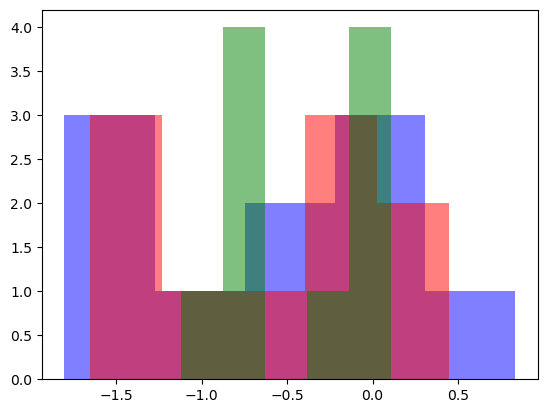

In [31]:
plt.hist(eval_rdm, bins=5, color="blue", alpha=0.5)
plt.hist(eval_maha, bins=5, color="red", alpha=0.5)
plt.hist(eval_match, bins=5, color="green", alpha=0.5)
plt.show()

In [342]:
# df_matched, timing = rdm_method(
#     df_pop=df_acic, 
#     features_numeric=f_num, 
#     features_categorical=f_cat, 
#     n_neighbors=1, 
#     threshold=0.1, 
#     k_candidates=500, 
#     timing=True, 
#     gower_weights=None
# )


# df_matched, time_it = run_matchit_inline(
#     df_acic, 
#     features_categorical=f_cat, 
#     features_numeric=f_num, 
#     features_interaction=[],
#     ratio=1
# )


# df_matched, time_it = run_mahalanobis_inline_nearest(
#     df_acic, 
#     features_numeric=f_num, 
#     features_categorical=f_cat, 
#     treatment_col='exposure_status'
# )

# df_matched, time_it = rdm_method_psm(
#     df_acic, 
#     features_numeric=f_num, 
#     features_categorical=f_cat, 
#     n_neighbors=1, 
#     caliper=0.1, 
#     k_candidates=500)

In [343]:
df_matched.shape

(1714, 27)

In [353]:
df_outcome = df_matched.merge(Y, on='patient_id')

att, p_val, ci = estimate_att_post_matching(df_outcome, 'y', 'exposure_status')

Raw Difference in Means (ATT): 2.8501


In [340]:
att

np.float64(3.3835051542743573)

In [330]:
true_att

2.721925445529166

In [68]:
rdm_method_psm(
    df_obs, 
    features_numeric=f_num, 
    features_categorical=f_cat, 
    n_neighbors=1, 
    caliper=0.2, 
    k_candidates=100)

(     patient_id  exposure_status  propensity_logit  match_group  n_matches  \
 0          2901                0         -8.588743           10        NaN   
 1         11525                0         -7.395109           98        NaN   
 2         29657                0         -8.772996           87        NaN   
 3         34569                0         -8.771407           85        NaN   
 4         38871                0         -7.112855           21        NaN   
 ..          ...              ...               ...          ...        ...   
 193      952337                1         -8.998038           94        1.0   
 194      954529                1         -8.258648           95        1.0   
 195      958660                1         -9.399727           96        1.0   
 196      968523                1         -7.420239           97        1.0   
 197      970862                1         -7.395111           98        1.0   
 
      match_distance  f01_age_years    f06_bmi  f0

In [267]:
# # Create a subset of the dataframe where exposure_status is 1
# df_exposed = df_obs[df_obs['exposure_status'] == 1].copy()

# # Combine feature lists and include the indicator variable
# target_columns = features_numeric + features_categorical + ['exposure_status', 'outcome']

# # Subset rows and filter columns simultaneously
# df_exposed_subset = df_obs.loc[df_obs['exposure_status'] == 1, target_columns].copy()

In [268]:
# import numpy as np
# import pandas as pd

# # Define the continuous target variable column name
# target_col = 'outcome' 

# # 1. Encode categorical features to prevent singularity (Dummy Variable Trap)
# # Ensure target_col is not duplicated in the feature sets
# X_df = pd.get_dummies(
#     df_exposed_subset[features_numeric + features_categorical], 
#     columns=features_categorical, 
#     drop_first=True,
#     dtype=float
# )
# y_series = df_exposed_subset[target_col]

# # 2. Extract arrays and mean-center the data
# X = X_df.to_numpy()
# y = y_series.to_numpy()

# X_mean = np.mean(X, axis=0)
# y_mean = np.mean(y)

# X_centered = X - X_mean
# y_centered = y - y_mean

# n = X.shape[0]

# # 3. Compute sample covariance (Sigma_xx) and cross-covariance (Sigma_xy)
# # The (n-1) scaling factor cancels out when solving for weights, 
# # but is applied here for strict definitional accuracy of covariance.
# Sigma_xx = (X_centered.T @ X_centered) / (n - 1)
# Sigma_xy = (X_centered.T @ y_centered) / (n - 1)

# # 4. Solve for weights using a numerically stable linear solver
# # This directly solves the system: Sigma_xx * weights = Sigma_xy 
# weights = np.linalg.solve(Sigma_xx, Sigma_xy)

# # 5. Calculate the intercept for the uncentered predictor space
# intercept = y_mean - np.dot(weights, X_mean)

# # Map calculated weights back to the expanded feature names
# weight_results = pd.Series(weights, index=X_df.columns, name="Weight")

In [270]:
# import numpy as np
# import pandas as pd

# # Assume X_df (the encoded design matrix) and 'weights' (the solved NumPy array) 
# # exist from the previous covariance matrix calculation.

# # Map the solved weights to their respective one-hot encoded column names
# weight_series = pd.Series(weights, index=X_df.columns)

# final_weights = []

# # 1. Extract exact coefficients for numeric features
# for col in features_numeric:
#     # Numeric features have a direct 1:1 mapping
#     final_weights.append(weight_series[col])

# # 2. Calculate Maximum Impact Range for categorical features
# for cat_col in features_categorical:
#     # Identify all one-hot encoded columns derived from the original categorical feature
#     dummy_cols = [c for c in X_df.columns if c.startswith(f"{cat_col}_")]
    
#     if not dummy_cols:
#         final_weights.append(0.0)
#         continue
        
#     # Extract the coefficients for the dummy variables
#     cat_weights = weight_series[dummy_cols].values
    
#     # Append 0.0 to represent the dropped baseline category effect
#     cat_weights_with_baseline = np.append(cat_weights, 0.0)
    
#     # Calculate the range to represent a single importance magnitude
#     impact_range = np.max(cat_weights_with_baseline) - np.min(cat_weights_with_baseline)
#     final_weights.append(impact_range)

# # final_weights is now a Python list ordered exactly by features_numeric + features_categorical

#### end

In [45]:
len(f_cat)

3

In [46]:
df_rdm, time_it = rdm_method(
    df_obs, 
    f_num, 
    f_cat, 
    n_neighbors=1, 
    threshold=0.1, 
    k_candidates=1500, 
    # gower_weights = final_final,
    gower_weights = np.concatenate([np.ones(len(f_num))*7, np.ones(len(f_cat))]),
    timing=True)

In [47]:
time_it

3.803649663925171

In [48]:
df_rdm.shape

(198, 19)

In [240]:
rdm_smd = matching_diagnostics(
    df_rdm, 
    'exposure_status', 
    features_numeric=f_num, 
    features_categorical=f_cat,
    plot_features=False
)

In [51]:
import os
import psutil
import time

# Constrain Intel MKL to a specific number of threads
# os.environ['MKL_NUM_THREADS'] = '1'

def computational_function():
    # Simulate workload
    _, _ = run_matchit_inline(df_obs, features_numeric=features_numeric, features_categorical=features_categorical)

def monitor_process():
    process = psutil.Process(os.getpid())
    
    # Initialization call (required for accurate baseline)
    process.cpu_percent(interval=None) 
    
    # Execute the target function
    computational_function()
    
    # Measure utilization over the elapsed execution time
    utilization = process.cpu_percent(interval=None)
    
    # Convert percentage to approximate core count
    cores_used = utilization / 100.0
    print(f"Process utilized {utilization}% CPU (approx. {cores_used:.2f} cores)")

monitor_process()

R callback write-console: Error in eval(predvars, data, env) : object 'f09_disease_stage' not found
  


R execution failed: Error in eval(predvars, data, env) : object 'f09_disease_stage' not found

Process utilized 100.0% CPU (approx. 1.00 cores)


In [25]:
_, time_it = run_mahalanobis_inline_nearest(df_obs, features_numeric=features_numeric, features_categorical=features_categorical, ratio=3)

In [26]:
# multi
time_it

24.09676742553711

In [35]:
_, time_it = run_mahalanobis_inline_nearest(df_obs, features_numeric=features_numeric, features_categorical=features_categorical, ratio=3)

In [36]:
# single
time_it

19.761661767959595

In [28]:
time_it_list = []
for i in range(100):
    # Execution
    df_obs, _, _ = generate_cohort(
        n_patients=1_000_000,
        dag_spec=cohort_dag,
        treatment_node="exposure_status",
        outcome_node="outcome",
        seed=i,
        target_treated_count=100
    )
    _, time_it = run_matchit_inline(df_obs, features_numeric=features_numeric, features_categorical=features_categorical)
    time_it_list.append(time_it)

#### Single

In [29]:
np.mean(time_it_list)

np.float64(4.182824642658233)

In [30]:
np.std(time_it_list)

np.float64(0.3337029476956469)

In [31]:
np.median(time_it_list)

np.float64(4.109605431556702)

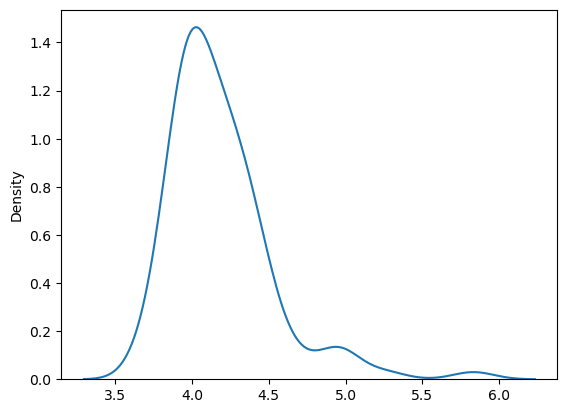

In [32]:
sns.kdeplot(time_it_list)
plt.show()

#### Multi

In [30]:
np.mean(time_it_list)

np.float64(3.7902092361450195)

In [32]:
np.std(time_it_list)

np.float64(0.35237246796066113)

In [33]:
np.median(time_it_list)

np.float64(3.841961622238159)

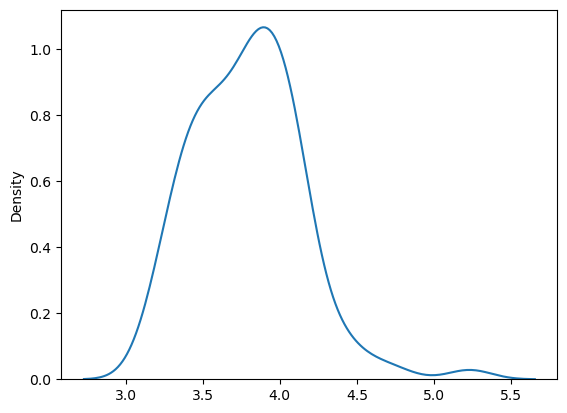

In [40]:
sns.kdeplot(time_it_list)
plt.show()

In [25]:
# matchit multi process
time_it

4.085647821426392

In [34]:
# matchit single process
time_it

5.154830694198608

In [27]:
time_it

4.405389785766602

In [37]:
import rpy2.robjects as robjects

# Execute the R command and print the output directly in Python
print(robjects.r('sessionInfo()'))

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /mnt/nfs/CX900004_DS31/.conda/envs/deid-env/lib/libmkl_intel_lp64.so.2;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] MatchIt_4.7.1

loaded via a namespace (and not attached):
[1] chk_0.10.0      compiler_4.4.3  backports_1.5.0 cli_3.6.5      
[5] Rcpp_1.1.1      lifecycle_1.0.5 rlang_1.1.7    



In [349]:
# tmp_2, time_it_2 = rdm_method_psm(df_rdm, features_numeric, features_categorical, n_neighbors=1, caliper=0.2, k_candidates=100, timing=True)

In [ ]:
def measure_time_for_matched(df, n_matches):
    

### psmpy

In [61]:
from psmpy import PsmPy

In [429]:
def psm_method(df_in, features_numeric, features_categorical, timing=True):
    """
    Executes Propensity Score Matching (PSM) on the provided population DataFrame.
    
    Arguments
    ---------
    df_in : pd.DataFrame
        The input DataFrame containing the population data.
    features_numeric : list of str
        List of column names corresponding to numeric features.
    features_categorical : list of str
        List of column names corresponding to categorical features.
        
    Returns
    -------
    pd.DataFrame
        A DataFrame containing matched pairs and their covariate balance metrics.
    """
    # Prepare data for PSM
    df = df_in.copy()

    # Initialize PsmPy and fit the propensity score model
    total_time = None
    if timing:
        import time
        start_time = time.time()
    psm = PsmPy(df, treatment='exposure_status', indx='patient_id', exclude = [])
    psm.logistic_ps(balance=True)
    # Perform matching (1:1 nearest neighbor without replacement)
    psm.knn_matched(matcher='propensity_logit', replacement=False, caliper=0.2, drop_unmatched=True)
    if timing:
        end_time = time.time()
        total_time = end_time - start_time
    
    # Extract matched pairs and calculate balance metrics    
    return psm.df_matched, total_time

In [420]:
def assign_match_groups(df, 
                        patient_id_col='patient_id', 
                        treatment_col='exposure_status', 
                        match_id_col='matched_ID', 
                        new_col='match_group'):
    """
    Assigns a sequential match group identifier to matching pairs in a matched dataset.
    
    Assumptions:
      - Treated records have treatment_col value of 1.
      - For a treated record, match_id_col contains the patient_id of the matched control.
      - Control records have treatment_col value of 0.
    
    For each treated record with a non-null match_id_col, this function:
      1. Assigns a unique integer (match group) to the treated record.
      2. Finds the control record(s) whose patient_id_col matches the treated record's match_id_col 
         and assigns the same group number.
    
    Parameters:
      df (pd.DataFrame): The DataFrame containing the matching output.
      patient_id_col (str): Column name for patient IDs.
      treatment_col (str): Column indicating treatment status (1 for treated, 0 for control).
      match_id_col (str): Column that holds the matched control’s patient ID for treated records.
      new_col (str): The name of the new column that will hold the match group identifier.
    
    Returns:
      pd.DataFrame: A copy of the DataFrame with an added column new_col indicating the match group.
    """
    # Work on a copy so as not to modify the original DataFrame.
    df = df.copy()
    # Create the new column with a default missing value.
    df[new_col] = np.nan

    group_id = 1
    # Iterate over treated rows that have a valid match
    treated_with_match = df.loc[(df[treatment_col] == 1) & (df[match_id_col].notnull())]
    for idx, row in treated_with_match.iterrows():
        # Assign a group id to the treated record if not already assigned.
        if pd.isna(df.at[idx, new_col]):
            df.at[idx, new_col] = group_id
            match_value = row[match_id_col]
            # Find the control record(s) where the patient_id matches the treated record's matched_ID.
            control_mask = (df[patient_id_col] == match_value) & (df[treatment_col] == 0)
            df.loc[control_mask, new_col] = group_id
            group_id += 1

    return df

In [407]:
df_test, time_test = psm_method(df_pop, features_numeric, features_categorical, timing=True)

/mnt/nfs/CX900004_DS31/.conda/envs/deid-env/lib/python3.13/site-packages/psmpy/psmpy.py:363: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False')


In [410]:
df_test_2 = assign_match_groups(df_test)

In [411]:
df_test_2

,patient_id,f01_age_years,f06_bmi,f07_sbp_mmhg,f05_prior_events,f09_disease_stage,f10_smoking_status,f08_variant_status,propensity_score,propensity_logit,exposure_status,matched_ID,match_group
0,376,82.931837,32.884608,131.269123,1.785850,4,0,0,0.947259,2.888170,1,960930.0,1.0
1,3876,59.820987,34.481487,128.064185,2.146887,4,0,0,0.753607,1.117945,1,283146.0,2.0
2,24845,61.772544,33.530149,158.264975,2.509716,4,2,0,0.681037,0.758541,1,538026.0,3.0
3,32116,85.127610,28.640676,123.293393,1.582636,4,1,0,0.980655,3.925776,1,467527.0,4.0
4,51060,79.840948,29.955915,149.082221,2.187040,4,2,0,0.938199,2.720038,1,850875.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,695641,58.426258,27.949729,120.595765,3.925391,4,2,0,0.905051,2.254649,0,NaN,194.0
392,676055,65.017932,18.918396,143.598314,0.998059,4,1,0,0.714611,0.917887,0,NaN,195.0
393,705242,54.084196,38.177614,138.261098,0.679809,4,1,0,0.672962,0.721612,0,NaN,196.0
394,199763,63.980475,22.071855,112.304508,1.076679,4,0,0,0.920246,2.445695,0,NaN,197.0


In [408]:
time_test

104.92090392112732

In [64]:
# psm = PsmPy(df_pop_one, treatment='exposure_status', indx='patient_id', exclude = [])
# psm.logistic_ps(balance = True)
# psm.knn_matched(matcher='propensity_logit', replacement=False, caliper=0.2, drop_unmatched=True)

# df_psm = assign_match_groups(psm.df_matched, 
#                              patient_id_col='patient_id',
#                              treatment_col='exposure_status',
#                              match_id_col='matched_ID',
#                              new_col='match_group')

# # since the psm table has the one-hot encoded columns, we need to drop the original categorical columns for comparison
# df_psm = df_psm.merge(df_pop[['patient_id', 'f08_variant_status', 'f09_disease_stage', 'f10_smoking_status']], on='patient_id', how='left')

### pysmatch

In [65]:
# path_pysmatch = '/mnt/nfs/CX900004_DS31/m2ai/repos/pysmatch/'
# sys.path.append(path_pysmatch)
# from pysmatch.Matcher import Matcher

In [66]:
# df_pop_expo1 = df_pop[df_pop['exposure_status']==1].copy()
# df_pop_expo0 = df_pop[df_pop['exposure_status']==0].copy()

In [67]:
# pysm = Matcher(df_pop_expo1, df_pop_expo0, yvar="exposure_status", exclude=['patient_id'])

In [68]:
# np.random.seed(20240919)

# # ============ (1) Noraml train (Without optuna) =============
# pysm.fit_scores(balance=True, nmodels=1, n_jobs=1, model_type='knn')
# # # m.fit_scores(balance=True, nmodels=10, n_jobs=3, model_type='tree', max_iter=100)
# # pysm.fit_scores(balance=True, nmodels=5, n_jobs=30, model_type='linear', max_iter=200)

# # ============ (2) Utilize optuna (Only train one best model) =============
# # m.fit_scores(
# #     balance=True,
# #     model_type='tree',
# #     max_iter=200,
# #     use_optuna=True,
# #     n_trials=15
# # )

# pysm.predict_scores()
# # m.plot_scores()

In [69]:
# pysm.match(method="min", nmatches=1, threshold=1, replacement=False)
# df_pysmatch = pysm.matched_data.copy()
# df_pysmatch['match_group'] = df_pysmatch['match_id']

### MatchIt

In [14]:
import os
import sys

# 1. Enforce Conda binary priority to bypass the system conflict
conda_bin = '/mnt/nfs/CX900004_DS31/.conda/envs/deid-env/bin'
os.environ['PATH'] = f"{conda_bin}:{os.environ.get('PATH', '')}"
os.environ['R_HOME'] = '/mnt/nfs/CX900004_DS31/.conda/envs/deid-env/lib/R'

# 2. Purge failed rpy2 initializations from the interpreter cache
for module in list(sys.modules.keys()):
    if module.startswith('rpy2'):
        del sys.modules[module]

# 3. Load the interface securely
%load_ext rpy2.ipython

In [15]:
import pandas as pd
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

matchit_lib = importr('MatchIt')

def run_matchit_inline(
    df, 
    features_categorical, 
    features_numeric, 
    features_interaction,
    treatment_col='exposure_status', 
    timing=True, 
    method='nearest', 
    ratio=1,
    caliper=0.2
):
    
    feature_names = features_categorical + features_numeric 
    
    with localconverter(robjects.default_converter + pandas2ri.converter):
        r_df = robjects.conversion.py2rpy(df)
    
    robjects.r.assign('r_df_temp', r_df)
    
    # Construct formula string for direct injection - also add interaction terms if specified
    formula_str = f"{treatment_col} ~ {' + '.join(feature_names + features_interaction)}"
    # print(f"Constructed formula for MatchIt: {formula_str}")
    

    # if ("f09_disease_stage" %in% colnames(df)) df$f09_disease_stage <- as.factor(df$f09_disease_stage)
    # if ("f10_smoking_status" %in% colnames(df)) df$f10_smoking_status <- as.factor(df$f10_smoking_status)
    # if ("f08_variant_status" %in% colnames(df)) df$f08_variant_status <- as.factor(df$f08_variant_status)
    
    # Inject formula_str directly into the matchit call, bypassing separate object creation
    r_script = f"""
    library(MatchIt)
    
    m.out <- matchit({formula_str}, 
                     data = r_df_temp, 
                     method = "{method}", 
                     distance = "glm", 
                     link = "linear.logit",
                     caliper = {caliper},
                     std.caliper = TRUE,
                     ratio={ratio},
                     replace = FALSE)
    
    matched_data <- match.data(m.out)
    """
    total_time = None
    try:
        if timing:
            import time
            start_time = time.time()
        robjects.r(r_script)
        if timing:
            end_time = time.time()
            total_time = end_time - start_time
    except Exception as e:
        print(f"R execution failed: {e}")
        return None, None # Return a tuple of Nones to prevent the unpacking TypeError
    
    with localconverter(robjects.default_converter + pandas2ri.converter):
        matched_df_python = robjects.conversion.rpy2py(robjects.r('matched_data'))
    
    if 'subclass' in matched_df_python.columns:
        matched_df_python['match_group'] = matched_df_python['subclass']
        matched_df_python.drop(columns=['subclass'], inplace=True)
        
    return matched_df_python, total_time

In [17]:
# %%R -i df_pop -o df_matchit

# # Load the library
# library(MatchIt)
# library(optmatch)

# # Specify the propensity score model
# # Replace 'treatment' and covariates with your specific variables
# m_out <- matchit(exposure_status ~ f01 + f02 + f06 + f07 + f08 + f10 + f03 + f04 + f05 + f09 + f10, 
#                  data = df_pop, 
#                  method = "optimal", 
#                  distance = "glm", 
#                  ratio = 1)

# # Extract the matched dataset to pass back to Python via the -o flag
# df_matchit <- match.data(m_out)

In [142]:
f_int = []

In [143]:
df_matchit, time_it = run_matchit_inline(
    df_obs, 
    features_categorical=f_cat, 
    features_numeric=f_num, 
    features_interaction=f_int,
    ratio=1
)

R callback write-console: Error in eval(predvars, data, env) : object 'x_2' not found
  


R execution failed: Error in eval(predvars, data, env) : object 'x_2' not found



In [144]:
df_matchit

In [145]:
time_it

### CEM

In [16]:
def run_cem_inline(df, features_numeric, features_categorical, treatment_col='exposure_status', timing=True):
    """
    Runs Coarsened Exact Matching via R's MatchIt.
    Note: CEM automatically handles coarsening, but you can provide manual 'cutpoints'.
    """
    with localconverter(robjects.default_converter + pandas2ri.converter):
        r_df = robjects.conversion.py2rpy(df)
    
    
    robjects.r.assign('r_df_temp', r_df)
    formula_str = f"{treatment_col} ~ {' + '.join(features_numeric + features_categorical)}"
        
    # We use 'cem' method. R will handle the coarsening bins automatically.
    # r_df_temp$f09_disease_stage <- factor(r_df_temp$f09_disease_stage, levels = c(1,2,3,4), ordered = TRUE)
    # r_df_temp$f10_smoking_status <- factor(r_df_temp$f10_smoking_status, levels = c(0,1,2))
    # r_df_temp$f08_variant_status <- factor(r_df_temp$f08_variant_status, levels = c(0,1))
    r_script = f"""
    library(MatchIt)
    m.out <- matchit(as.formula("{formula_str}"), 
                     data = r_df_temp, 
                     method = "cem",
                     estimand = "ATT")
    matched_data <- match.data(m.out)
    """
    
                    #      k2k = TRUE,
                    #  k2k.method = "mahalanobis")
    
    total_time = None
    if timing:
        import time
        start_time = time.time()
    robjects.r(r_script)
    if timing:
        end_time = time.time()
        total_time = end_time - start_time

    with localconverter(robjects.default_converter + pandas2ri.converter):
        matched_df_python = robjects.conversion.rpy2py(robjects.r('matched_data'))
        # before returning, rename the 'subclass' column to 'match_group' for consistency with other methods
        if 'subclass' in matched_df_python.columns:
            matched_df_python['match_group'] = matched_df_python['subclass']
            matched_df_python.drop(columns=['subclass'], inplace=True)

        return matched_df_python, total_time

In [22]:
# df_cem, time_it = run_cem_inline(df_pop, features_numeric, features_categorical,)

### Genetic

In [23]:
def run_genetic_inline(df, feature_names, treatment_col='exposure_status'):
    """
    Runs Genetic Matching via R's MatchIt. 
    Warning: This is computationally intensive and may be slow on large datasets.
    """
    with localconverter(robjects.default_converter + pandas2ri.converter):
        r_df = robjects.conversion.py2rpy(df)
    
    robjects.r.assign('r_df_temp', r_df)
    formula_str = f"{treatment_col} ~ {' + '.join(feature_names)}"
    
    r_script = f"""
    library(MatchIt)
    # pop.size increases accuracy but significantly slows down the search
    m.out <- matchit(as.formula("{formula_str}"), 
                     data = r_df_temp, 
                     method = "genetic", 
                     pop.size = 100) 
    matched_data <- match.data(m.out)
    """
    robjects.r(r_script)
    
    with localconverter(robjects.default_converter + pandas2ri.converter):
        matched_df_python = robjects.conversion.rpy2py(robjects.r('matched_data'))
        # before returning, rename the 'subclass' column to 'match_group' for consistency with other methods
        if 'subclass' in matched_df_python.columns:
            matched_df_python['match_group'] = matched_df_python['subclass']
            matched_df_python.drop(columns=['subclass'], inplace=True)

        return matched_df_python

In [24]:
# df_genetic = run_genetic_inline(df_pop, feature_names)

### Mahalanobis

In [17]:
def run_mahalanobis_inline_nearest(df, features_numeric, features_categorical, 
                                   treatment_col='exposure_status', timing=True,
                                  ratio=1):
    """
    Runs Multivariate Mahalanobis Distance Matching via R's MatchIt.
    """
    with localconverter(robjects.default_converter + pandas2ri.converter):
        r_df = robjects.conversion.py2rpy(df)
    
    robjects.r.assign('r_df_temp', r_df)
    formula_str = f"{treatment_col} ~ {' + '.join(features_numeric + features_categorical)}"


    # if ("f09_disease_stage" %in% colnames(df)) df$f09_disease_stage <- as.factor(df$f09_disease_stage)
    # if ("f10_smoking_status" %in% colnames(df)) df$f10_smoking_status <- as.factor(df$f10_smoking_status)
    # if ("f08_variant_status" %in% colnames(df)) df$f08_variant_status <- as.factor(df$f08_variant_status)
    
    r_script = f"""
    library(MatchIt)
    sessionInfo()
    m.out <- matchit(as.formula("{formula_str}"), 
                     data = r_df_temp, 
                     distance = "mahalanobis",
                     method = "nearest",
                     ratio={ratio},
                     replace = FALSE)
    matched_data <- match.data(m.out)
    """
    total_time = None
    if timing:
        import time
        start_time = time.time()
    robjects.r(r_script)
    if timing:
        end_time = time.time()
        total_time = end_time - start_time
    
    with localconverter(robjects.default_converter + pandas2ri.converter):
        matched_df_python = robjects.conversion.rpy2py(robjects.r('matched_data'))
        # before returning, rename the 'subclass' column to 'match_group' for consistency with other methods
        if 'subclass' in matched_df_python.columns:
            matched_df_python['match_group'] = matched_df_python['subclass']
            matched_df_python.drop(columns=['subclass'], inplace=True)

        return matched_df_python, total_time

In [18]:
def run_mahamatchit(
    df, 
    features_numeric, 
    features_categorical, 
    features_interaction,
    treatment_col='exposure_status', 
    timing=True,
    ratio=1,
    caliper=0.2
):
    """
    Runs Multivariate Mahalanobis Distance Matching via R's MatchIt.
    """
    with localconverter(robjects.default_converter + pandas2ri.converter):
        r_df = robjects.conversion.py2rpy(df)
    
    robjects.r.assign('r_df_temp', r_df)
    formula_str = f"{treatment_col} ~ {' + '.join(features_numeric + features_categorical + features_interaction)}"


    # if ("f09_disease_stage" %in% colnames(df)) df$f09_disease_stage <- as.factor(df$f09_disease_stage)
    # if ("f10_smoking_status" %in% colnames(df)) df$f10_smoking_status <- as.factor(df$f10_smoking_status)
    # if ("f08_variant_status" %in% colnames(df)) df$f08_variant_status <- as.factor(df$f08_variant_status)

    # Ensure formula_str includes all numeric and categorical features
    r_script = f"""
    library(MatchIt)
    m.out <- matchit(as.formula("{formula_str}"), 
                     data = r_df_temp, 
                     method = "nearest",
                     distance = "glm",
                     link = "linear.logit",
                     caliper = {caliper},
                     std.caliper = TRUE,
                     mahvars = as.formula("~ {' + '.join(features_numeric + features_categorical)}"),
                     ratio = {ratio},
                     replace = FALSE)
    matched_data <- match.data(m.out)
    """
    # r_script = f"""
    # library(MatchIt)
    # sessionInfo()
    # m.out <- matchit(as.formula("{formula_str}"), 
    #                  data = r_df_temp, 
    #                  distance = "mahalanobis",
    #                  method = "nearest",
    #                  ratio={ratio},
    #                  replace = FALSE)
    # matched_data <- match.data(m.out)
    # """
    total_time = None
    if timing:
        import time
        start_time = time.time()
    robjects.r(r_script)
    if timing:
        end_time = time.time()
        total_time = end_time - start_time
    
    with localconverter(robjects.default_converter + pandas2ri.converter):
        matched_df_python = robjects.conversion.rpy2py(robjects.r('matched_data'))
        # before returning, rename the 'subclass' column to 'match_group' for consistency with other methods
        if 'subclass' in matched_df_python.columns:
            matched_df_python['match_group'] = matched_df_python['subclass']
            matched_df_python.drop(columns=['subclass'], inplace=True)

        return matched_df_python, total_time

In [20]:
# from rpy2.robjects.packages import importr
# from rpy2.robjects import Formula, globalenv, StrVector
# from rpy2.robjects.conversion import localconverter
# from rpy2.robjects import pandas2ri

# def run_mahalanobis_inline_optimal(df, features_numeric, features_categorical,
#                                    treatment_col='exposure_status', timing=True):

#     df = df.copy()
#     for col in features_categorical:
#         df[col] = df[col].astype(str).astype("category")

#     # enforce categorical typing
#     for col in features_categorical:
#         df[col] = df[col].astype("category")

#     with localconverter(robjects.default_converter + pandas2ri.converter):
#         r_df = pandas2ri.py2rpy(df)

#     globalenv['r_df_temp'] = r_df

#     # numeric-only formula
#     formula_str = f"{treatment_col} ~ {' + '.join(features_numeric + features_categorical)}"
#     fmla = Formula(formula_str)

#     MatchIt = importr("MatchIt")

#     if timing:
#         import time
#         start = time.time()

#     m_out = MatchIt.matchit(
#         fmla,
#         data=globalenv['r_df_temp'],
#         distance="mahalanobis",
#         method="full",
#         #exact=StrVector(features_categorical)
#     )

#     matched_r = MatchIt.match_data(m_out)

#     if timing:
#         total_time = time.time() - start
#     else:
#         total_time = None

#     with localconverter(robjects.default_converter + pandas2ri.converter):
#         matched_df = pandas2ri.rpy2py(matched_r)

#     if 'subclass' in matched_df.columns:
#         matched_df['match_group'] = matched_df['subclass']
#         matched_df.drop(columns=['subclass'], inplace=True)

#     return matched_df, total_time

In [23]:
# # 1e3 to 1e6 is borderline, anything more is really hard to invert
# robjects.r("""
# kappa(X)
# """)

In [27]:
df_maha_opt, time_it = run_mahalanobis_inline_nearest(
    df_obs, 
    features_numeric=f_num, 
    features_categorical=f_cat, 
    treatment_col='exposure_status'
)

In [28]:
time_it

6.120756387710571

In [73]:
df_maha_opt.sort_values('match_group')

,patient_id,f01_age_years,f06_bmi,f07_sbp_mmhg,f09_disease_stage,f10_smoking_status,f05_prior_events,f08_variant_status,f03_lvef_fraction,exposure_status,f02_biomarker_crp,outcome,f04_followup_visits,Y_0,Y_1,ITE,weights,match_group
149,150,56.884583,30.251225,152.455341,1,0,0.0,0,68.475879,1,0.507586,-0.591312,5.477890,2.139695,-0.591312,-2.731007,1.0,1
7682,7683,53.566097,29.961058,154.326430,1,0,0.0,0,67.121580,0,1.340043,-0.371197,1.829186,-0.371197,-3.102203,-2.731007,1.0,1
3607,3608,72.616982,32.773463,136.550967,2,0,0.0,0,58.133352,0,4.239511,3.540049,6.051384,3.540049,0.809043,-2.731007,1.0,2
1011,1012,72.307657,32.897588,132.777542,2,0,0.0,0,65.343201,1,1.889961,0.324333,5.902603,3.055339,0.324333,-2.731007,1.0,2
5325,5326,74.534248,34.785980,145.806637,1,0,0.0,0,63.584407,0,6.990107,6.941885,10.389272,6.941885,4.210878,-2.731007,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9758,9759,79.266341,24.870953,135.767189,4,1,0.0,1,65.216141,1,3.310667,3.832759,10.201355,6.563765,3.832759,-2.731007,1.0,94
5626,5627,59.827785,29.142692,123.999398,2,0,5.0,0,56.925830,0,3.106164,2.398954,4.603570,2.398954,-0.332053,-2.731007,1.0,95
9850,9851,59.184424,28.143665,125.483563,2,0,5.0,0,60.140379,1,0.803864,2.348873,9.167098,5.079880,2.348873,-2.731007,1.0,95
6208,6209,67.312864,32.246273,118.129185,4,0,1.0,0,39.905580,0,5.023722,4.558315,10.291863,4.558315,1.827309,-2.731007,1.0,96


In [231]:
df_mahamatchit, time_it = run_mahamatchit(
    df_obs, 
    features_numeric=f_num, 
    features_categorical=f_cat, 
    ratio=1
)

In [232]:
time_it

22.63142967224121

In [233]:
df_mahamatchit

,patient_id,set0_b_cat1,set0_b_nbinom,set0_b_lognorm,set0_b_cat2,set1_opt_cat1,set1_opt_nbinom,set1_opt_lognorm,set1_opt_cat2,set2_opt_cat1,...,set2_opt_norm,set2_opt_cat3,exposure_status,outcome,Y_0,Y_1,ITE,distance,weights,match_group
9236,9237,1,8.0,3.599814,1,1,2.0,54.370591,1,2,...,577.808145,1,1,6.355205,8.355205,6.355205,-2.0,0.000491,1.0,1
11361,11362,2,2.0,5.085019,1,1,5.0,85.359073,2,2,...,634.201402,1,0,10.742626,10.742626,8.742626,-2.0,0.003322,1.0,19
20890,20891,1,3.0,11.173483,1,2,1.0,75.743014,3,0,...,481.264476,1,1,10.559060,12.559060,10.559060,-2.0,0.010369,1.0,2
20904,20905,0,3.0,1.852860,3,2,4.0,66.251887,2,2,...,562.286952,1,0,11.312186,11.312186,9.312186,-2.0,0.002461,1.0,41
20993,20994,1,10.0,7.575701,3,2,2.0,78.286614,1,2,...,557.045300,1,1,11.493525,13.493525,11.493525,-2.0,0.028353,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961032,961033,2,2.0,3.643214,3,2,4.0,87.430694,2,2,...,657.019604,1,1,13.410602,15.410602,13.410602,-2.0,0.033286,1.0,62
968725,968726,2,6.0,6.267307,2,2,3.0,58.856895,2,2,...,581.247776,1,1,8.938830,10.938830,8.938830,-2.0,0.001848,1.0,63
988866,988867,2,8.0,5.229513,1,1,3.0,95.909977,1,2,...,634.867739,0,1,7.781348,9.781348,7.781348,-2.0,0.003537,1.0,64
991093,991094,2,4.0,5.946925,3,2,2.0,69.286055,2,1,...,639.564996,1,1,11.441592,13.441592,11.441592,-2.0,0.002761,1.0,65


In [227]:
df_mahalonobis, time_it = run_mahalanobis_inline_nearest(
    df_obs, 
    features_numeric=f_num, 
    features_categorical=f_cat, 
    ratio=1
)

In [228]:
time_it

29.631600856781006

In [189]:
df_mahalonobis.shape

(166, 26)

In [234]:
maha_smd = matching_diagnostics(
    df_mahamatchit, 
    'exposure_status', 
    features_numeric=f_num, 
    features_categorical=f_cat,
    plot_features=False
)

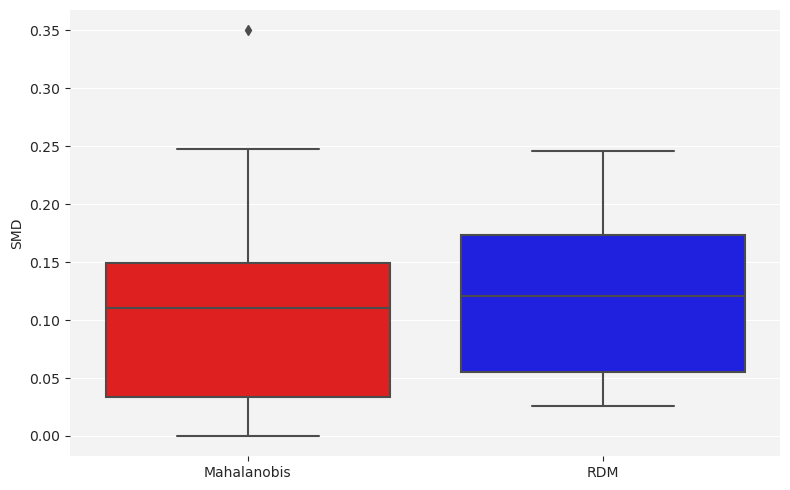

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Option A: pass as list of series
plt.figure(figsize=(8,5))
sns.boxplot(data=[maha_smd['SMD'], rdm_smd['SMD']], palette=['red','blue'])
plt.xticks([0,1], ['Mahalanobis','RDM'])
plt.ylabel('SMD')
plt.tight_layout()
plt.show()

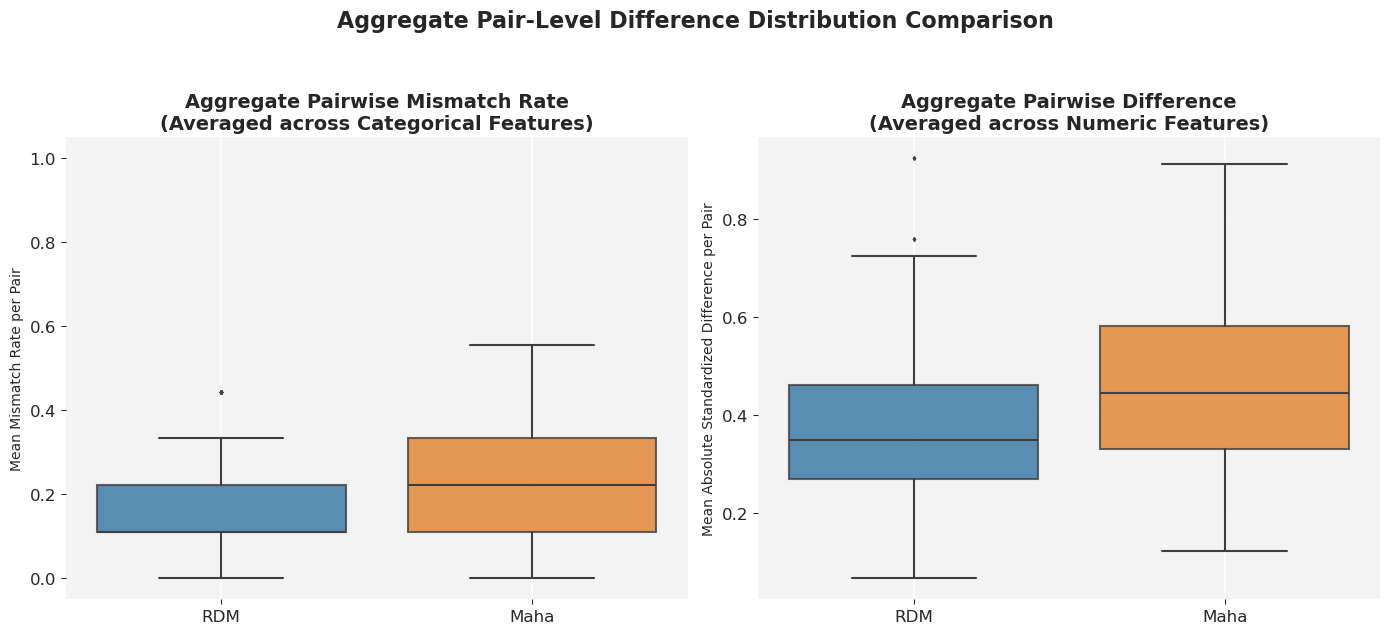

In [191]:
plot_aggregate_pairwise_comparison(
    df_method1 = df_rdm,
    df_method2 = df_mahalonobis,
    df_original = df_obs,
    features_numeric = f_num,
    features_categorical = f_cat,
    method1_label = 'RDM',
    method2_label = 'Maha')

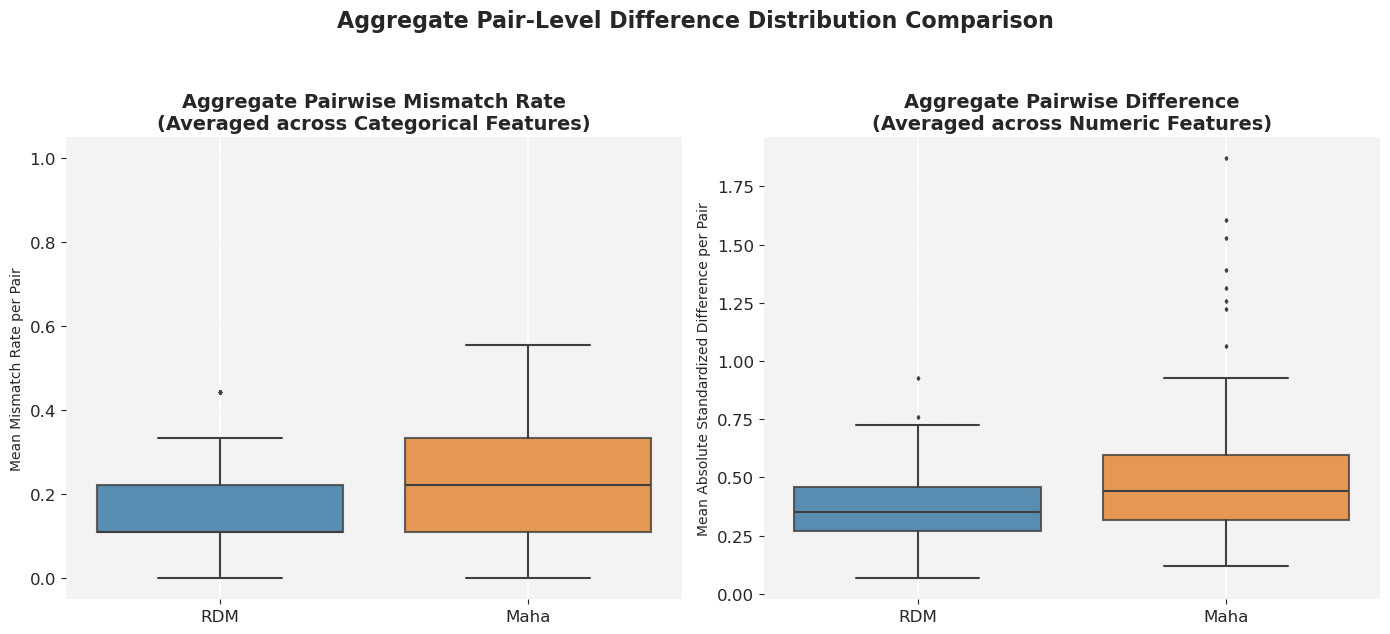

In [244]:
plot_aggregate_pairwise_comparison(
    df_method1 = df_rdm,
    df_method2 = df_mahamatchit,
    df_original = df_obs,
    features_numeric = f_num,
    features_categorical = f_cat,
    method1_label = 'RDM',
    method2_label = 'Maha')

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def set_r_style():
    sns.set_style("darkgrid", {
        "axes.facecolor": "#F3F3F3",      
        "grid.color": "white",            
        "axes.edgecolor": "none",         
        "xtick.bottom": True,
        "ytick.left": True
    })

def original_sd_calculator(df: pd.DataFrame, features_numeric: list[str], exposure_col: str) -> dict[str, float]:
    """
    Calculates the original standard deviations for numeric features using the full population.
    This is used as a fixed denominator for standardized mean difference calculations.
    """
    raw_controls = df[df[exposure_col] == 0][features_numeric]
    raw_cases = df[df[exposure_col] == 1][features_numeric]
    
    var_ctrl = raw_controls.var()
    var_case = raw_cases.var()
    
    baseline_sd = np.sqrt((var_ctrl + var_case) / 2)
    
    # Handle monomorphic variables by replacing 0 with 1.0 to prevent division by zero
    baseline_sd[baseline_sd == 0] = 1.0
    
    return baseline_sd.to_dict()

def calculate_pairwise_differences(
    df_match: pd.DataFrame, 
    df_original: pd.DataFrame,
    features_numeric: list[str], 
    features_categorical: list[str],
    original_sds: dict[str, float] = None
) -> pd.DataFrame:
    """
    Calculates pair-wise differences between treated and control units. 
    If original_sds is provided, numeric differences are standardized.
    """
    matched_df = df_match.dropna(subset=['match_group'])
    treated = matched_df[matched_df['exposure_status'] == 1]
    controls = matched_df[matched_df['exposure_status'] == 0]
    
    merged = pd.merge(
        treated[['match_group'] + features_numeric + features_categorical],
        controls[['match_group'] + features_numeric + features_categorical],
        on='match_group',
        suffixes=('_t', '_c')
    )
    
    diff_df = pd.DataFrame({'match_group': merged['match_group']})
    
    if original_sds is None:
        original_sds = original_sd_calculator(df_original, features_numeric, 'exposure_status')
    
    # Numeric differences
    for col in features_numeric:
        raw_diff = merged[f'{col}_t'] - merged[f'{col}_c']
        if original_sds and col in original_sds:
            diff_df[col] = raw_diff / original_sds[col]
        else:
            diff_df[col] = raw_diff
            
    # Categorical differences (1 = mismatch, 0 = match)
    for col in features_categorical:
        diff_df[col] = (merged[f'{col}_t'] != merged[f'{col}_c']).astype(int)
        
    return diff_df

def plot_method_pairwise_comparison(
    df_method1: pd.DataFrame,
    df_method2: pd.DataFrame,
    df_original: pd.DataFrame,
    features_numeric: list[str],
    features_categorical: list[str],
    method1_label: str = 'Method 1',
    method2_label: str = 'Method 2',
    color_palette: dict = None
):
    """
    Plots pairwise differences for categorical (barplot) and numeric (boxplot) features,
    comparing two distinct matching methods.
    """
    set_r_style()
    
    if color_palette is None:
        color_palette = {method1_label: '#1f77b4', method2_label: '#ff7f0e'}

    original_sds = original_sd_calculator(df_original, features_numeric, 'exposure_status')
    
    diff_m1 = calculate_pairwise_differences(df_method1, df_original, features_numeric, features_categorical, original_sds)
    diff_m2 = calculate_pairwise_differences(df_method2, df_original, features_numeric, features_categorical, original_sds)
    
    m1_melt = diff_m1.melt(id_vars=['match_group'], var_name='Feature', value_name='Difference')
    m1_melt['Method'] = method1_label
    
    m2_melt = diff_m2.melt(id_vars=['match_group'], var_name='Feature', value_name='Difference')
    m2_melt['Method'] = method2_label
    
    combined_df = pd.concat([m1_melt, m2_melt], ignore_index=True)
    
    df_cat = combined_df[combined_df['Feature'].isin(features_categorical)].copy()
    df_num = combined_df[combined_df['Feature'].isin(features_numeric)].copy()
    
    df_num['Difference'] = df_num['Difference'].abs()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    if not df_cat.empty:
        # FIX: Replaced err_kws with errwidth for legacy Seaborn compatibility
        sns.barplot(data=df_cat, x='Feature', y='Difference', hue='Method', palette=color_palette, 
                    ax=ax1, capsize=0.1, errwidth=1.5, alpha=0.8)
        ax1.set_title('Pairwise Mismatch Rate (Categorical)', fontsize=15, fontweight='bold')
        ax1.set_ylabel('Mismatch Rate (Proportion)')
        ax1.set_xlabel('')
        ax1.set_ylim(-0.05, 1.05)
        ax1.tick_params(axis='x', rotation=45)
        
    if not df_num.empty:
        sns.boxplot(data=df_num, x='Feature', y='Difference', hue='Method', palette=color_palette, 
                    ax=ax2, boxprops=dict(alpha=0.8), fliersize=2)
        ax2.set_title('Mean Absolute Pairwise Difference (Numeric)', fontsize=15, fontweight='bold')
        ax2.set_ylabel('Standardized Difference (MAPD)')
        ax2.set_xlabel('')
        ax2.tick_params(axis='x', rotation=45)
        
    for ax in [ax1, ax2]:
        sns.despine(ax=ax, left=True, bottom=True)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, which='major', linestyle='-', linewidth=1.2)
        ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.suptitle('Pairwise Difference Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_aggregate_pairwise_comparison(
    df_method1: pd.DataFrame,
    df_method2: pd.DataFrame,
    df_original: pd.DataFrame,
    features_numeric: list[str],
    features_categorical: list[str],
    method1_label: str = 'Method 1',
    method2_label: str = 'Method 2',
    color_palette: dict = None
):
    """
    Plots the aggregate distribution of match quality at the pair level.
    Averages differences across all features for each matched pair to 
    resolve visualization issues when the feature space is large.
    """
    set_r_style()
    
    if color_palette is None:
        color_palette = {method1_label: '#1f77b4', method2_label: '#ff7f0e'}

    original_sds = original_sd_calculator(df_original, features_numeric, 'exposure_status')
    
    # Calculate pair-level differences
    diff_m1 = calculate_pairwise_differences(df_method1, df_original, features_numeric, features_categorical, original_sds)
    diff_m2 = calculate_pairwise_differences(df_method2, df_original, features_numeric, features_categorical, original_sds)
    
    # Aggregate across features for each pair
    def aggregate_diffs(diff_df, method_name):
        cat_agg = diff_df[features_categorical].mean(axis=1) if features_categorical else pd.Series(dtype=float)
        num_agg = diff_df[features_numeric].abs().mean(axis=1) if features_numeric else pd.Series(dtype=float)
        
        return pd.DataFrame({
            'Method': method_name,
            'Cat_Mismatch_Rate': cat_agg,
            'Num_MAPD': num_agg
        })

    agg_m1 = aggregate_diffs(diff_m1, method1_label)
    agg_m2 = aggregate_diffs(diff_m2, method2_label)
    
    combined_df = pd.concat([agg_m1, agg_m2], ignore_index=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    if features_categorical:
        sns.boxplot(data=combined_df, x='Method', y='Cat_Mismatch_Rate', palette=color_palette, 
                    ax=ax1, boxprops=dict(alpha=0.8), fliersize=2)
        ax1.set_title('Aggregate Pairwise Mismatch Rate\n(Averaged across Categorical Features)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Mean Mismatch Rate per Pair')
        ax1.set_xlabel('')
        ax1.set_ylim(-0.05, 1.05)
        
    if features_numeric:
        sns.boxplot(data=combined_df, x='Method', y='Num_MAPD', palette=color_palette, 
                    ax=ax2, boxprops=dict(alpha=0.8), fliersize=2)
        ax2.set_title('Aggregate Pairwise Difference\n(Averaged across Numeric Features)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Mean Absolute Standardized Difference per Pair')
        ax2.set_xlabel('')
        
    for ax in [ax1, ax2]:
        sns.despine(ax=ax, left=True, bottom=True)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, which='major', linestyle='-', linewidth=1.2)
        ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.suptitle('Aggregate Pair-Level Difference Distribution Comparison', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    # return fig

In [388]:
df_mahalonobis.shape

(2189, 17)

In [395]:
df_rdm.shape

(2189, 18)

## Compare

In [24]:
# features_numeric = ['f01_age_years', 'f02_biomarker_crp', 'f03_lvef_fraction', 'f04_survival_days', 'f05_prior_events', 'f06_bmi', 'f07_sbp_mmhg']
# features_categorical = ['f08_variant_status', 'f09_disease_stage', 'f10_smoking_status']

### Simulation: Causal

In [44]:
def get_match_quality_summary(df, match_col='match_group', features_numeric=f_num, features_categorical=f_cat):
    """
    Calculates a single standardized distance score for every match group using
    pooled standard deviation logic for numeric variables, and mismatch rates for categoricals.
    """
    # 1. Pre-calculate Pooled Standard Deviations ONLY for Numeric columns
    baseline_stats = {}
    
    for col in features_numeric:
        std_exposed = df[df['exposure_status'] == 1][col].std()
        std_control = df[df['exposure_status'] == 0][col].std()
        
        # Pooled SD: sqrt((s1^2 + s2^2) / 2)
        pooled = np.sqrt(((std_exposed**2) + (std_control**2)) / 2)
        
        # Fallback to total cohort SD if pooled is 0
        baseline_stats[col] = pooled if pooled > 0 else df[col].std()

    def calculate_group_distance(group):
        treated = group[group['exposure_status'] == 1]
        controls = group[group['exposure_status'] == 0]
        
        if treated.empty or controls.empty:
            return np.nan

        group_distances = []
        
        # 2. Numeric Distance (Standardized Mean Difference)
        for col in features_numeric:
            mean_treated = treated[col].mean()
            mean_control = controls[col].mean()
            denom = baseline_stats[col]
            
            # FIX: Prevent Division by Zero if the feature has 0 variance globally
            smd = abs(mean_treated - mean_control) / denom if denom > 0 else 0.0
            group_distances.append(smd)
            
        # 3. Categorical Distance (Mismatch Rate)
        if features_categorical:
            for col in features_categorical:
                treated_val = treated[col].iloc[0]
                mismatch_rate = (controls[col] != treated_val).mean()
                group_distances.append(mismatch_rate)
                
        return np.mean(group_distances)

    # FIX: Explicitly set observed=True to silence the Pandas FutureWarning
    summary_out = df.groupby(match_col, observed=True).apply(calculate_group_distance, include_groups=False)
    
    return summary_out.rename("match_quality_smd")



def _calculate_smd_numeric(prop_exposed, prop_control, var_list):
    """Calculate the standardized mean differences (SMD) for numeric variables."""
    smds = {}
    for var in var_list:
        mean1 = prop_exposed[var].mean()
        mean2 = prop_control[var].mean()
        std1 = prop_exposed[var].std()
        std2 = prop_control[var].std()

        pooled_std = np.sqrt((std1**2 + std2**2) / 2)
        smd = abs(mean1 - mean2) / pooled_std if pooled_std != 0 else 0.0
        smds[var] = smd
    return smds


def _calculate_smd_categorical(prop_exposed, prop_control, var_list):
    """
    Standardized Mean Difference for proportions.
    Follows the standard: |p1 - p2| / sqrt((p1(1-p1) + p2(1-p2)) / 2)
    """
    smds = {}
    all_cats = set(prop_exposed.index).union(set(prop_control.index))
    
    for category in all_cats:
        p1 = prop_exposed.get(category, 0)
        p2 = prop_control.get(category, 0)
        
        # Avoid division by zero for categories with 0% prevalence in both groups
        if p1 == 0 and p2 == 0:
            smds[category] = 0.0
            continue
            
        # Standard variance for proportions
        variance = (p1 * (1 - p1) + p2 * (1 - p2)) / 2
        
        # If variance is 0 (e.g., both are 1.0), SMD is 0
        smd = abs(p1 - p2) / np.sqrt(variance) if variance > 0 else 0.0
        smds[category] = smd
        
    return smds

def summary_stats_table(data, features_numeric, features_categorical, exposure_col, smd_threshold=0.1):
    """
    Builds a summary table of matching diagnostics (Means, Stds, SMDs).
    """
    rows = []
    
    exposed_data = data[data[exposure_col] == 1]
    control_data = data[data[exposure_col] == 0]

    if exposed_data.empty or control_data.empty:
        return None

    # 1. Numeric Diagnostics
    if features_numeric:
        smds_num = _calculate_smd_numeric(exposed_data, control_data, features_numeric)
        
        for feature in features_numeric:
            rows.append({
                'Feature': feature,
                'Mean_Exposed': exposed_data[feature].mean(),
                'Std_Exposed': exposed_data[feature].std(),
                'Mean_Control': control_data[feature].mean(),
                'Std_Control': control_data[feature].std(),
                'SMD': smds_num.get(feature, np.nan)
            })

    # 2. Categorical Diagnostics
    if features_categorical:
        for feature in features_categorical:
            prop_exposed = exposed_data[feature].value_counts(normalize=True)
            prop_control = control_data[feature].value_counts(normalize=True)

            smds_cat = _calculate_smd_categorical(prop_exposed, prop_control, feature)

            for category, smd_val in smds_cat.items():
                rows.append({
                    'Feature': f"{feature}_{str(category)[:15]}", # Shorten name
                    'Mean_Exposed': prop_exposed.get(category, 0) * 100,
                    'Std_Exposed': np.nan,
                    'Mean_Control': prop_control.get(category, 0) * 100,
                    'Std_Control': np.nan,
                    'SMD': smd_val
                })

    summary_df = pd.DataFrame(rows)
    if not summary_df.empty:
        summary_df['SMD Result'] = summary_df['SMD'].apply(lambda x: "OK" if x < smd_threshold else "BAD")
        return np.round(summary_df, 3)
    return pd.DataFrame()


def measure_method_time(func, *args, **kwargs):
    """
    Utility function to measure execution time of a given method.
    Outputs the result and the time taken.
    """
    start_time = time()
    result = func(*args, **kwargs)
    end_time = time()
    elapsed_time = end_time - start_time
    return result, elapsed_time



def original_sd_calculator(df: pd.DataFrame, features_numeric: list[str], exposure_col: str) -> dict[str, float]:
    """
    Calculates the original standard deviations for numeric features using the full population.
    This is used as a fixed denominator for standardized mean difference calculations.
    """
    raw_controls = df[df[exposure_col] == 0][features_numeric]
    raw_cases = df[df[exposure_col] == 1][features_numeric]
    
    var_ctrl = raw_controls.var()
    var_case = raw_cases.var()
    
    baseline_sd = np.sqrt((var_ctrl + var_case) / 2)
    
    # Handle monomorphic SNPs: Replace 0 with 1.0 to prevent division by zero.
    baseline_sd[baseline_sd == 0] = 1.0
    
    return baseline_sd.to_dict()


def calculate_pairwise_differences(
    df_match: pd.DataFrame, 
    df_original: pd.DataFrame,
    features_numeric: list[str], 
    features_categorical: list[str],
    original_sds: dict[str, float] = None
) -> pd.DataFrame:
    """
    Calculates pair-wise differences between treated and control units. 
    If original_sds is provided, numeric differences are standardized.
    """
    matched_df = df_match.dropna(subset=['match_group'])
    treated = matched_df[matched_df['exposure_status'] == 1]
    controls = matched_df[matched_df['exposure_status'] == 0]
    
    merged = pd.merge(
        treated[['match_group'] + features_numeric + features_categorical],
        controls[['match_group'] + features_numeric + features_categorical],
        on='match_group',
        suffixes=('_t', '_c')
    )
    
    diff_df = pd.DataFrame({'match_group': merged['match_group']})
    
    if original_sds is None:
        original_sds = original_sd_calculator(df_original, features_numeric, 'exposure_status')
    
    # Numeric differences
    for col in features_numeric:
        raw_diff = merged[f'{col}_t'] - merged[f'{col}_c']
        if original_sds and col in original_sds:
            # Standardize using the pre-matched SD
            diff_df[col] = raw_diff / original_sds[col]
        else:
            diff_df[col] = raw_diff
            
    # Categorical differences (1 = mismatch, 0 = match)
    for col in features_categorical:
        diff_df[col] = (merged[f'{col}_t'] != merged[f'{col}_c']).astype(int)
        
    return diff_df


def summarize_iter_quality(df_match: pd.DataFrame, df_original: pd.DataFrame, 
                           features_numeric: list[str], features_categorical: list[str]) -> dict:
    """
    Extracts summary statistics from the pairwise differences for a single MC iteration.
    """
    diff_df = calculate_pairwise_differences(df_match, df_original, features_numeric, features_categorical)
    
    summary_numeric = {}
    
    # Numeric summaries
    for col in features_numeric:
        abs_diff = diff_df[col].abs()
        summary_numeric[f'{col}_meanpd'] = abs_diff.mean()
        summary_numeric[f'{col}_medianpd'] = abs_diff.median()
        summary_numeric[f'{col}_maxpd'] = abs_diff.max()
        
    # Categorical summaries
    summary_categorical = {}
    for col in features_categorical:
        summary_categorical[f'{col}_pmr'] = diff_df[col].mean()
        
    return summary_numeric, summary_categorical

In [45]:
# df_matched, run_time = rdm_method_psm(
#     df_obs, 
#     features_numeric=features_numeric,
#     features_categorical=features_categorical, 
#     n_neighbors=1,
#     caliper=0.2, 
#     k_candidates=1500
# )

In [46]:
num_coef = 5
features_interaction = []
# psm_weight = 200

def eval_rdm(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction, n_neighbors=1):
    try:
        df_matched, run_time = rdm_method(
            df, 
            features_numeric=features_numeric,
            features_categorical=features_categorical, 
            n_neighbors=n_neighbors,
            threshold=0.1, 
            k_candidates=1500,
            gower_weights = np.concatenate([np.ones(len(features_numeric))*num_coef, np.ones(len(features_categorical))])
        )

        # df_matched, run_time = rdm_method_psm(
        #     df, 
        #     features_numeric=features_numeric,
        #     features_categorical=features_categorical, 
        #     n_neighbors=n_neighbors,
        #     caliper=0.2, 
        #     k_candidates=1500,
        #     downsample_ratio=5,
        # )
        
        df_matched = df_matched.merge(df_outcome_map, on='patient_id', how='left')
        att = df_matched[df_matched['exposure_status']==1]['outcome'].mean() - \
              df_matched[df_matched['exposure_status']==0]['outcome'].mean()
        retention = len(df_matched[df_matched['exposure_status']==1]) / df[df['exposure_status']==1].shape[0]
        smd = summary_stats_table(df_matched, features_numeric=features_numeric, 
                                  features_categorical=features_categorical, exposure_col='exposure_status')
        pairs = get_match_quality_summary(df_matched)
        num, cat = summarize_iter_quality(df_matched, df_complete, features_numeric, features_categorical)
        
        return {'att': att, 'retention': retention, 'smd': smd, 'time': run_time, 
                'pairs': pairs, 'num': num, 'cat': cat}
    except Exception as e:
        return {'att': np.nan, 'retention': np.nan, 'smd': np.nan, 'time': np.nan, 
                'pairs': np.nan, 'num': np.nan, 'cat': np.nan, 'error': str(e)}

def eval_matchit(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction):
    try:
        df_matched, run_time = run_matchit_inline(df, features_categorical=features_categorical, 
                                                  features_numeric=features_numeric, 
                                                  features_interaction=features_interaction)
        df_matched = df_matched.merge(df_outcome_map, on='patient_id', how='left')
        
        att = df_matched[df_matched['exposure_status']==1]['outcome'].mean() - \
              df_matched[df_matched['exposure_status']==0]['outcome'].mean()
        
        retention = len(df_matched[df_matched['exposure_status']==1]) / df[df['exposure_status']==1].shape[0]
        smd = summary_stats_table(df_matched, features_numeric=features_numeric, 
                                  features_categorical=features_categorical, exposure_col='exposure_status')
        pairs = get_match_quality_summary(df_matched)
        num, cat = summarize_iter_quality(df_matched, df_complete, features_numeric, features_categorical)
        
        return {'att': att, 'retention': retention, 'smd': smd, 'time': run_time, 
                'pairs': pairs, 'num': num, 'cat': cat}
    except Exception as e:
        return {'att': np.nan, 'retention': np.nan, 'smd': np.nan, 'time': np.nan, 
                'pairs': np.nan, 'num': np.nan, 'cat': np.nan, 'error': str(e)}

def eval_cem(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction):
    try:
        df_matched, run_time = run_cem_inline(df, features_numeric=features_numeric, 
                                              features_categorical=features_categorical)
        df_matched = df_matched.merge(df_outcome_map, on='patient_id', how='left')
        
        # CEM utilizes stratum weights for valid ATT estimation
        treated = df_matched[df_matched["exposure_status"] == 1]
        control = df_matched[df_matched["exposure_status"] == 0]
        y1 = np.average(treated["outcome"], weights=treated["weights"])
        y0 = np.average(control["outcome"], weights=control["weights"])
        att = y1 - y0
        
        retention = len(df_matched[df_matched['exposure_status']==1]) / df[df['exposure_status']==1].shape[0]
        smd = summary_stats_table(df_matched, features_numeric=features_numeric, 
                                  features_categorical=features_categorical, exposure_col='exposure_status')
        pairs = get_match_quality_summary(df_matched)
        num, cat = summarize_iter_quality(df_matched, df_complete, features_numeric, features_categorical)
        
        return {'att': att, 'retention': retention, 'smd': smd, 'time': run_time, 
                'pairs': pairs, 'num': num, 'cat': cat}
    except Exception as e:
        return {'att': np.nan, 'retention': np.nan, 'smd': np.nan, 'time': np.nan, 
                'pairs': np.nan, 'num': np.nan, 'cat': np.nan, 'error': str(e)}

def eval_mahalanobis(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction, ratio=1):
    try:
        df_matched, run_time = run_mahalanobis_inline_nearest(df, features_numeric=features_numeric, 
                                                              features_categorical=features_categorical, ratio=ratio)
        df_matched = df_matched.merge(df_outcome_map, on='patient_id', how='left')
        
        att = df_matched[df_matched['exposure_status']==1]['outcome'].mean() - \
              df_matched[df_matched['exposure_status']==0]['outcome'].mean()
        
        retention = len(df_matched[df_matched['exposure_status']==1]) / df[df['exposure_status']==1].shape[0]
        smd = summary_stats_table(df_matched, features_numeric=features_numeric, 
                                  features_categorical=features_categorical, exposure_col='exposure_status')
        pairs = get_match_quality_summary(df_matched)
        num, cat = summarize_iter_quality(df_matched, df_complete, features_numeric, features_categorical)
        
        return {'att': att, 'retention': retention, 'smd': smd, 'time': run_time, 
                'pairs': pairs, 'num': num, 'cat': cat}
    except Exception as e:
        return {'att': np.nan, 'retention': np.nan, 'smd': np.nan, 'time': np.nan, 
                'pairs': np.nan, 'num': np.nan, 'cat': np.nan, 'error': str(e)}

def eval_hybrid_rdm_matchit(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction):
    try:
        df_matched_tmp, matchit_time = run_matchit_inline(
            df, 
            features_numeric=features_numeric, 
            features_categorical=features_categorical,
            features_interaction=features_interaction,
            ratio=5,
            caliper=0.2
        )

        # df_matched_tmp, matchit_time = rdm_method_psm(
        #     df, 
        #     features_numeric, 
        #     features_categorical, 
        #     n_neighbors=3, 
        #     caliper=0.2, 
        #     k_candidates=1500, 
        #     timing=True
        # )
        
        
        df_matched, rdm_time = rdm_method(
            df_matched_tmp, 
            features_numeric=features_numeric,
            features_categorical=features_categorical,
            n_neighbors=1, 
            threshold=0.1, 
            k_candidates=1500,
            gower_weights = np.concatenate([np.ones(len(features_numeric))*num_coef, np.ones(len(features_categorical))])
        )
        
        # df_matched, matchit_time = run_matchit_inline(df_rdm_matched, features_numeric=features_numeric, 
        #                                               features_categorical=features_categorical)
        
        df_matched = df_matched.merge(df_outcome_map, on='patient_id', how='left')
        
        att = df_matched[df_matched['exposure_status']==1]['outcome'].mean() - \
              df_matched[df_matched['exposure_status']==0]['outcome'].mean()
        
        retention = len(df_matched[df_matched['exposure_status']==1]) / df[df['exposure_status']==1].shape[0]
        smd = summary_stats_table(df_matched, features_numeric=features_numeric, 
                                  features_categorical=features_categorical, exposure_col='exposure_status')
        pairs = get_match_quality_summary(df_matched)
        num, cat = summarize_iter_quality(df_matched, df_complete, features_numeric, features_categorical)
        
        total_time = rdm_time + matchit_time
        
        return {'att': att, 'retention': retention, 'smd': smd, 'time': total_time, 
                'pairs': pairs, 'num': num, 'cat': cat}
    except Exception as e:
        return {'att': np.nan, 'retention': np.nan, 'smd': np.nan, 'time': np.nan, 
                'pairs': np.nan, 'num': np.nan, 'cat': np.nan, 'error': str(e)}

def eval_hybrid_maha_matchit(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction):
    try:
        # df_maha_matched, maha_time = run_mahalanobis_inline_nearest(df, features_numeric=features_numeric, 
        #                                                             features_categorical=features_categorical,
        #                                                             ratio=5)
        
        # df_maha_matched.drop(columns=['weights', 'match_group'], errors='ignore', inplace=True)
        
        # df_matched, matchit_time = run_matchit_inline(df_maha_matched, features_numeric=features_numeric, 
        #                                               features_categorical=features_categorical)

        df_matched, maha_time = run_mahamatchit(
            df, 
            features_numeric=features_numeric, 
            features_categorical=features_categorical,
            features_interaction=features_interaction,
            ratio=1,
            caliper=0.2
        )
        df_matched.drop(columns=['weights'], errors='ignore', inplace=True)
        
        df_matched = df_matched.merge(df_outcome_map, on='patient_id', how='left')
        
        att = df_matched[df_matched['exposure_status']==1]['outcome'].mean() - \
              df_matched[df_matched['exposure_status']==0]['outcome'].mean()
        
        retention = len(df_matched[df_matched['exposure_status']==1]) / df[df['exposure_status']==1].shape[0]
        smd = summary_stats_table(df_matched, features_numeric=features_numeric, 
                                  features_categorical=features_categorical, exposure_col='exposure_status')
        pairs = get_match_quality_summary(df_matched)
        num, cat = summarize_iter_quality(df_matched, df_complete, features_numeric, features_categorical)
        
        total_time = maha_time #+ matchit_time
        
        return {'att': att, 'retention': retention, 'smd': smd, 'time': total_time, 
                'pairs': pairs, 'num': num, 'cat': cat}
    except Exception as e:
        return {'att': np.nan, 'retention': np.nan, 'smd': np.nan, 'time': np.nan, 
                'pairs': np.nan, 'num': np.nan, 'cat': np.nan, 'error': str(e)}

In [47]:
# # 1. Generate local stochastic cohort ONCE for this seed
# df_complete, true_ate, true_att = generate_cohort(
#     n_patients=1000000,
#     dag_spec=cohort_config,
#     treatment_node="exposure_status",
#     outcome_node="outcome",
#     # include_sets=[0, 1, 2],
#     seed=1,
#     target_treated_count=100
# )

# df_outcome_map = df_complete[['patient_id', 'outcome', 'Y_0', 'Y_1', 'ITE']]

# # 2. Prevent Data Leakage and Suffix Collisions (Critical)
# # exclude_list = list(set(features_exclude + ['outcome', 'Y_0', 'Y_1', 'ITE']))
# # exclude_list = [c for c in exclude_list if c not in ['patient_id', 'exposure_status']]
# df = df_complete.drop(columns=features_exclude, errors='ignore').copy()

In [48]:
# eval_rdm(df, df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction=[])


In [49]:
# single methods. Works great!!

import pandas as pd
import numpy as np
import concurrent.futures

def worker_task(task_params, features_numeric=f_num, features_categorical=f_cat, features_exclude=f_exc, features_interaction=[]):
    """
    Executes all methods for a single dataset seed.
    """
    seed = task_params['seed']
    methods_to_test = task_params['methods']
    n_pats = task_params['n_pats']
    cohort_dag = task_params['cohort_dag']

    try:
        # 1. Generate local stochastic cohort ONCE for this seed
        df_complete, true_ate, true_att = generate_cohort(
            n_patients=n_pats,
            dag_spec=cohort_dag,
            treatment_node="exposure_status",
            outcome_node="outcome",
            # include_sets=[0, 1, 2],
            seed=seed,
            target_treated_count=100
        )
        
        df_outcome_map = df_complete[['patient_id', 'outcome', 'Y_0', 'Y_1', 'ITE']]
        
        # 2. Prevent Data Leakage and Suffix Collisions (Critical)
        # exclude_list = list(set(features_exclude + ['outcome', 'Y_0', 'Y_1', 'ITE']))
        # exclude_list = [c for c in exclude_list if c not in ['patient_id', 'exposure_status']]
        df = df_complete.drop(columns=features_exclude, errors='ignore').copy()
        
        # 3. Enforce strict NumPy primitives to prevent rpy2 conversion failures
        for col in df.columns:
            if isinstance(df[col].dtype, pd.core.dtypes.dtypes.ExtensionDtype):
                if pd.api.types.is_numeric_dtype(df[col]):
                    df[col] = df[col].astype('float64')
                elif pd.api.types.is_bool_dtype(df[col]):
                    df[col] = df[col].astype('int32')
        
        # 4. Extract Crude Effect
        crude_att = df_complete[df_complete['exposure_status']==1]['outcome'].mean() - \
                    df_complete[df_complete['exposure_status']==0]['outcome'].mean()

        # 5. Method Dispatcher
        method_map = {
            'RDM': eval_rdm,
            'MatchIt': eval_matchit,
            'Mahalanobis': eval_mahalanobis,
            'Hybrid_RDM_MatchIt': eval_hybrid_rdm_matchit,
            'Hybrid_Maha_MatchIt': eval_hybrid_maha_matchit
        }
        
        seed_results = []
        
        # 6. Execute all requested methods on the same cohort
        for method_name in methods_to_test:
            if method_name not in method_map:
                continue
                
            target_func = method_map[method_name]
            
            # Pass a distinct copy of 'df' to prevent algorithms from mutating the shared dataframe
            res = target_func(df.copy(), df_outcome_map, df_complete, features_numeric, features_categorical, features_interaction)
            
            seed_results.append({
                'seed': seed,
                'method': method_name,
                'true_att': true_att,
                'crude_att': crude_att,
                **res 
            })
            
        return seed_results

    except Exception as global_e:
        # Catch critical failures inside the worker task itself and log for all requested methods
        return [{
            'seed': seed,
            'method': m,
            'true_att': np.nan,
            'crude_att': np.nan,
            'error': f"Worker Failure: {str(global_e)}"
        } for m in methods_to_test]


def run_parallel_monte_carlo(n_iterations, n_pats, cohort_dag, starting_seed=1, max_workers=None):
    
    methods_to_test = ['RDM', 'MatchIt', 'Mahalanobis', 'Hybrid_RDM_MatchIt', 'Hybrid_Maha_MatchIt'] # Added CEM back if needed
    seeds = range(starting_seed, starting_seed + n_iterations)
    
    # Generate tasks by seed, passing the list of methods to each worker
    tasks = []
    for seed in seeds:
        tasks.append({
            'seed': seed,
            'methods': methods_to_test,
            'n_pats': n_pats,
            'cohort_dag': cohort_dag 
        })
        
    results = []
    
    if max_workers is None:
        cpu_count = os.cpu_count() or 4
        max_workers = max(1, cpu_count - 1)
        
    print(f"Initializing simulation pool with {max_workers} workers...")
    
    # Execute pool
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(worker_task, task): task for task in tasks}
        
        for future in concurrent.futures.as_completed(futures):
            task_info = futures[future]
            try:
                # The worker now returns a list of dictionaries (one per method)
                res_list = future.result()
                results.extend(res_list) # Use extend to flatten the list
            except Exception as exc:
                print(f"Task for seed {task_info['seed']} generated an exception: {exc}")
                
    # Transform flat list of dicts to long-format DataFrame
    df_results = pd.DataFrame(results)
    
    # Sort for analytical readability
    if not df_results.empty:
        df_results = df_results.sort_values(by=['seed', 'method']).reset_index(drop=True)
        
    return df_results

In [50]:
# # 1:many matching

# import pandas as pd
# import numpy as np
# import concurrent.futures
# import os

# def worker_task(task_params, features_numeric=f_num, features_categorical=f_cat, features_exclude=f_exc, features_interaction=[]):
#     """
#     Executes specified methods across different matching ratios for a single dataset seed.
#     """
#     seed = task_params['seed']
#     methods_to_test = task_params['methods']  # Now expects a list of tuples: (method_name, ratio)
#     n_pats = task_params['n_pats']
#     cohort_dag = task_params['cohort_dag']

#     try:
#         # 1. Generate local stochastic cohort ONCE for this seed
#         df_complete, true_ate, true_att = generate_cohort(
#             n_patients=n_pats,
#             dag_spec=cohort_dag,
#             treatment_node="exposure_status",
#             outcome_node="outcome",
#             seed=seed,
#             target_treated_count=100
#         )
        
#         df_outcome_map = df_complete[['patient_id', 'outcome', 'Y_0', 'Y_1', 'ITE']]
        
#         # 2. Prevent Data Leakage
#         df = df_complete.drop(columns=features_exclude, errors='ignore').copy()
        
#         # 3. Enforce strict NumPy primitives
#         for col in df.columns:
#             if isinstance(df[col].dtype, pd.core.dtypes.dtypes.ExtensionDtype):
#                 if pd.api.types.is_numeric_dtype(df[col]):
#                     df[col] = df[col].astype('float64')
#                 elif pd.api.types.is_bool_dtype(df[col]):
#                     df[col] = df[col].astype('int32')
        
#         # 4. Extract Crude Effect
#         crude_att = df_complete[df_complete['exposure_status']==1]['outcome'].mean() - \
#                     df_complete[df_complete['exposure_status']==0]['outcome'].mean()

#         seed_results = []
        
#         # 5. Execute methods with specified ratios
#         for method_base, ratio in methods_to_test:
#             run_name = f"{method_base}_1:{ratio}"
            
#             try:
#                 if method_base == 'RDM':
#                     res = eval_rdm(
#                         df.copy(), df_outcome_map, df_complete, 
#                         features_numeric, features_categorical, features_interaction, 
#                         n_neighbors=ratio
#                     )
#                 elif method_base == 'Mahalanobis':
#                     res = eval_mahalanobis(
#                         df.copy(), df_outcome_map, df_complete, 
#                         features_numeric, features_categorical, features_interaction, 
#                         ratio=ratio
#                     )
#                 else:
#                     continue
                    
#                 seed_results.append({
#                     'seed': seed,
#                     'method': run_name,
#                     'true_att': true_att,
#                     'crude_att': crude_att,
#                     **res 
#                 })
                
#             except Exception as e:
#                 seed_results.append({
#                     'seed': seed,
#                     'method': run_name,
#                     'true_att': true_att,
#                     'crude_att': crude_att,
#                     'error': f"Method Failure: {str(e)}"
#                 })
                
#         return seed_results

#     except Exception as global_e:
#         # Catch critical failures in cohort generation or setup
#         return [{
#             'seed': seed,
#             'method': f"{m[0]}_1:{m[1]}",
#             'true_att': np.nan,
#             'crude_att': np.nan,
#             'error': f"Worker Failure: {str(global_e)}"
#         } for m in methods_to_test]


# def run_parallel_monte_carlo(n_iterations, n_pats, cohort_dag, starting_seed=1, max_workers=None):
    
#     # Define combinations of algorithm and target ratio
#     methods_to_test = [
#         ('RDM', 1), ('RDM', 5), ('RDM', 10),
#         ('Mahalanobis', 1), ('Mahalanobis', 5), ('Mahalanobis', 10)
#     ]
    
#     seeds = range(starting_seed, starting_seed + n_iterations)
    
#     tasks = []
#     for seed in seeds:
#         tasks.append({
#             'seed': seed,
#             'methods': methods_to_test,
#             'n_pats': n_pats,
#             'cohort_dag': cohort_dag 
#         })
        
#     results = []
    
#     if max_workers is None:
#         cpu_count = os.cpu_count() or 4
#         max_workers = max(1, cpu_count - 1)
        
#     print(f"Initializing simulation pool with {max_workers} workers...")
    
#     with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
#         futures = {executor.submit(worker_task, task): task for task in tasks}
        
#         for future in concurrent.futures.as_completed(futures):
#             task_info = futures[future]
#             try:
#                 res_list = future.result()
#                 results.extend(res_list)
#             except Exception as exc:
#                 print(f"Task for seed {task_info['seed']} generated an exception: {exc}")
                
#     df_results = pd.DataFrame(results)
    
#     if not df_results.empty:
#         df_results = df_results.sort_values(by=['seed', 'method']).reset_index(drop=True)
        
#     return df_results

good settings: <br>
num_coef = 5 with support_level = 0.5 with 0.15 gower dist

In [51]:
results_df = run_parallel_monte_carlo(
    n_iterations=30, 
    n_pats=1_000_000, 
    cohort_dag=cohort_config, 
    starting_seed=1, 
    max_workers=30
)

Initializing simulation pool with 30 workers...


In [52]:
results_df.head()

,seed,method,true_att,crude_att,att,retention,smd,time,pairs,num,cat
0,1,Hybrid_Maha_MatchIt,-2.731007,1.795628,-2.731411,1.000000,Feature Mean_Exposed Std_Ex...,14.038512,match_group 1 0.041472 2 0.080906 3 ...,"{'f01_age_years_meanpd': 0.11654412596202114, ...","{'f09_disease_stage_pmr': 0.0, 'f10_smoking_st..."
1,1,Hybrid_RDM_MatchIt,-2.731007,1.795628,-3.139723,0.957447,Feature Mean_Exposed Std_Ex...,10.401624,match_group 0.0 0.216217 1.0 0.186650 ...,"{'f01_age_years_meanpd': 0.33000970131927354, ...","{'f09_disease_stage_pmr': 0.35555555555555557,..."
2,1,Mahalanobis,-2.731007,1.795628,-2.688655,1.000000,Feature Mean_Exposed Std_Ex...,15.711325,match_group 1 0.041250 2 0.062466 3 ...,"{'f01_age_years_meanpd': 0.12125236045064802, ...",{'f09_disease_stage_pmr': 0.010638297872340425...
3,1,MatchIt,-2.731007,1.795628,-3.577740,1.000000,Feature Mean_Exposed Std_Ex...,11.625701,match_group 1 0.602209 2 0.795431 3 ...,"{'f01_age_years_meanpd': 1.0438475194910095, '...","{'f09_disease_stage_pmr': 0.5531914893617021, ..."
4,1,RDM,-2.731007,1.795628,-2.532170,1.000000,Feature Mean_Exposed Std_Ex...,10.992025,match_group 0 0.041473 1 0.062832 2 ...,"{'f01_age_years_meanpd': 0.10744734936918007, ...","{'f09_disease_stage_pmr': 0.02127659574468085,..."


### Plot Outcomes

In [ ]:
# # 1. Base initialization
# research_config = {
#     #'crude': {'name': 'Unadjusted', 'color': "#878D96"}
# }

# # 2. Iterate colors corresponding to [1, 2, 3, 5, 10]
# ratios = [1, 5, 10]

# # Colors listed Light (k=1) to Dark (k=10)
# # Includes #68B5E3 interpolated to resolve the 4 vs 5 color array discrepancy
# rdm_pal = ["#178CCB", "#0F388A", "#052049"] #"#E2F4FC", "#B8E6FA", 
# mah_pal = ["#C42882", "#821A56", "#561038"] # "#F2C2DE", "#E266AE", 

# # 3. Populate config dynamically
# for i, k in enumerate(ratios):
#     research_config[f'RDM_1:{k}'] = {
#         'name': f'RDM 1:{k}',
#         'color': rdm_pal[i],
#         'base': 'rdm',
#         'k': k
#     }
    
# for i, k in enumerate(ratios):
#     research_config[f'Mahalanobis_1:{k}'] = {
#         'name': f'Mahalanobis 1:{k}',
#         'color': mah_pal[i],
#         'base': 'mahalonobis',
#         'k': k
#     }

# print(research_config)

{'RDM_1:1': {'name': 'RDM 1:1', 'color': '#178CCB', 'base': 'rdm', 'k': 1}, 'RDM_1:5': {'name': 'RDM 1:5', 'color': '#0F388A', 'base': 'rdm', 'k': 5}, 'RDM_1:10': {'name': 'RDM 1:10', 'color': '#052049', 'base': 'rdm', 'k': 10}, 'Mahalanobis_1:1': {'name': 'Mahalanobis 1:1', 'color': '#C42882', 'base': 'mahalonobis', 'k': 1}, 'Mahalanobis_1:5': {'name': 'Mahalanobis 1:5', 'color': '#821A56', 'base': 'mahalonobis', 'k': 5}, 'Mahalanobis_1:10': {'name': 'Mahalanobis 1:10', 'color': '#561038', 'base': 'mahalonobis', 'k': 10}}


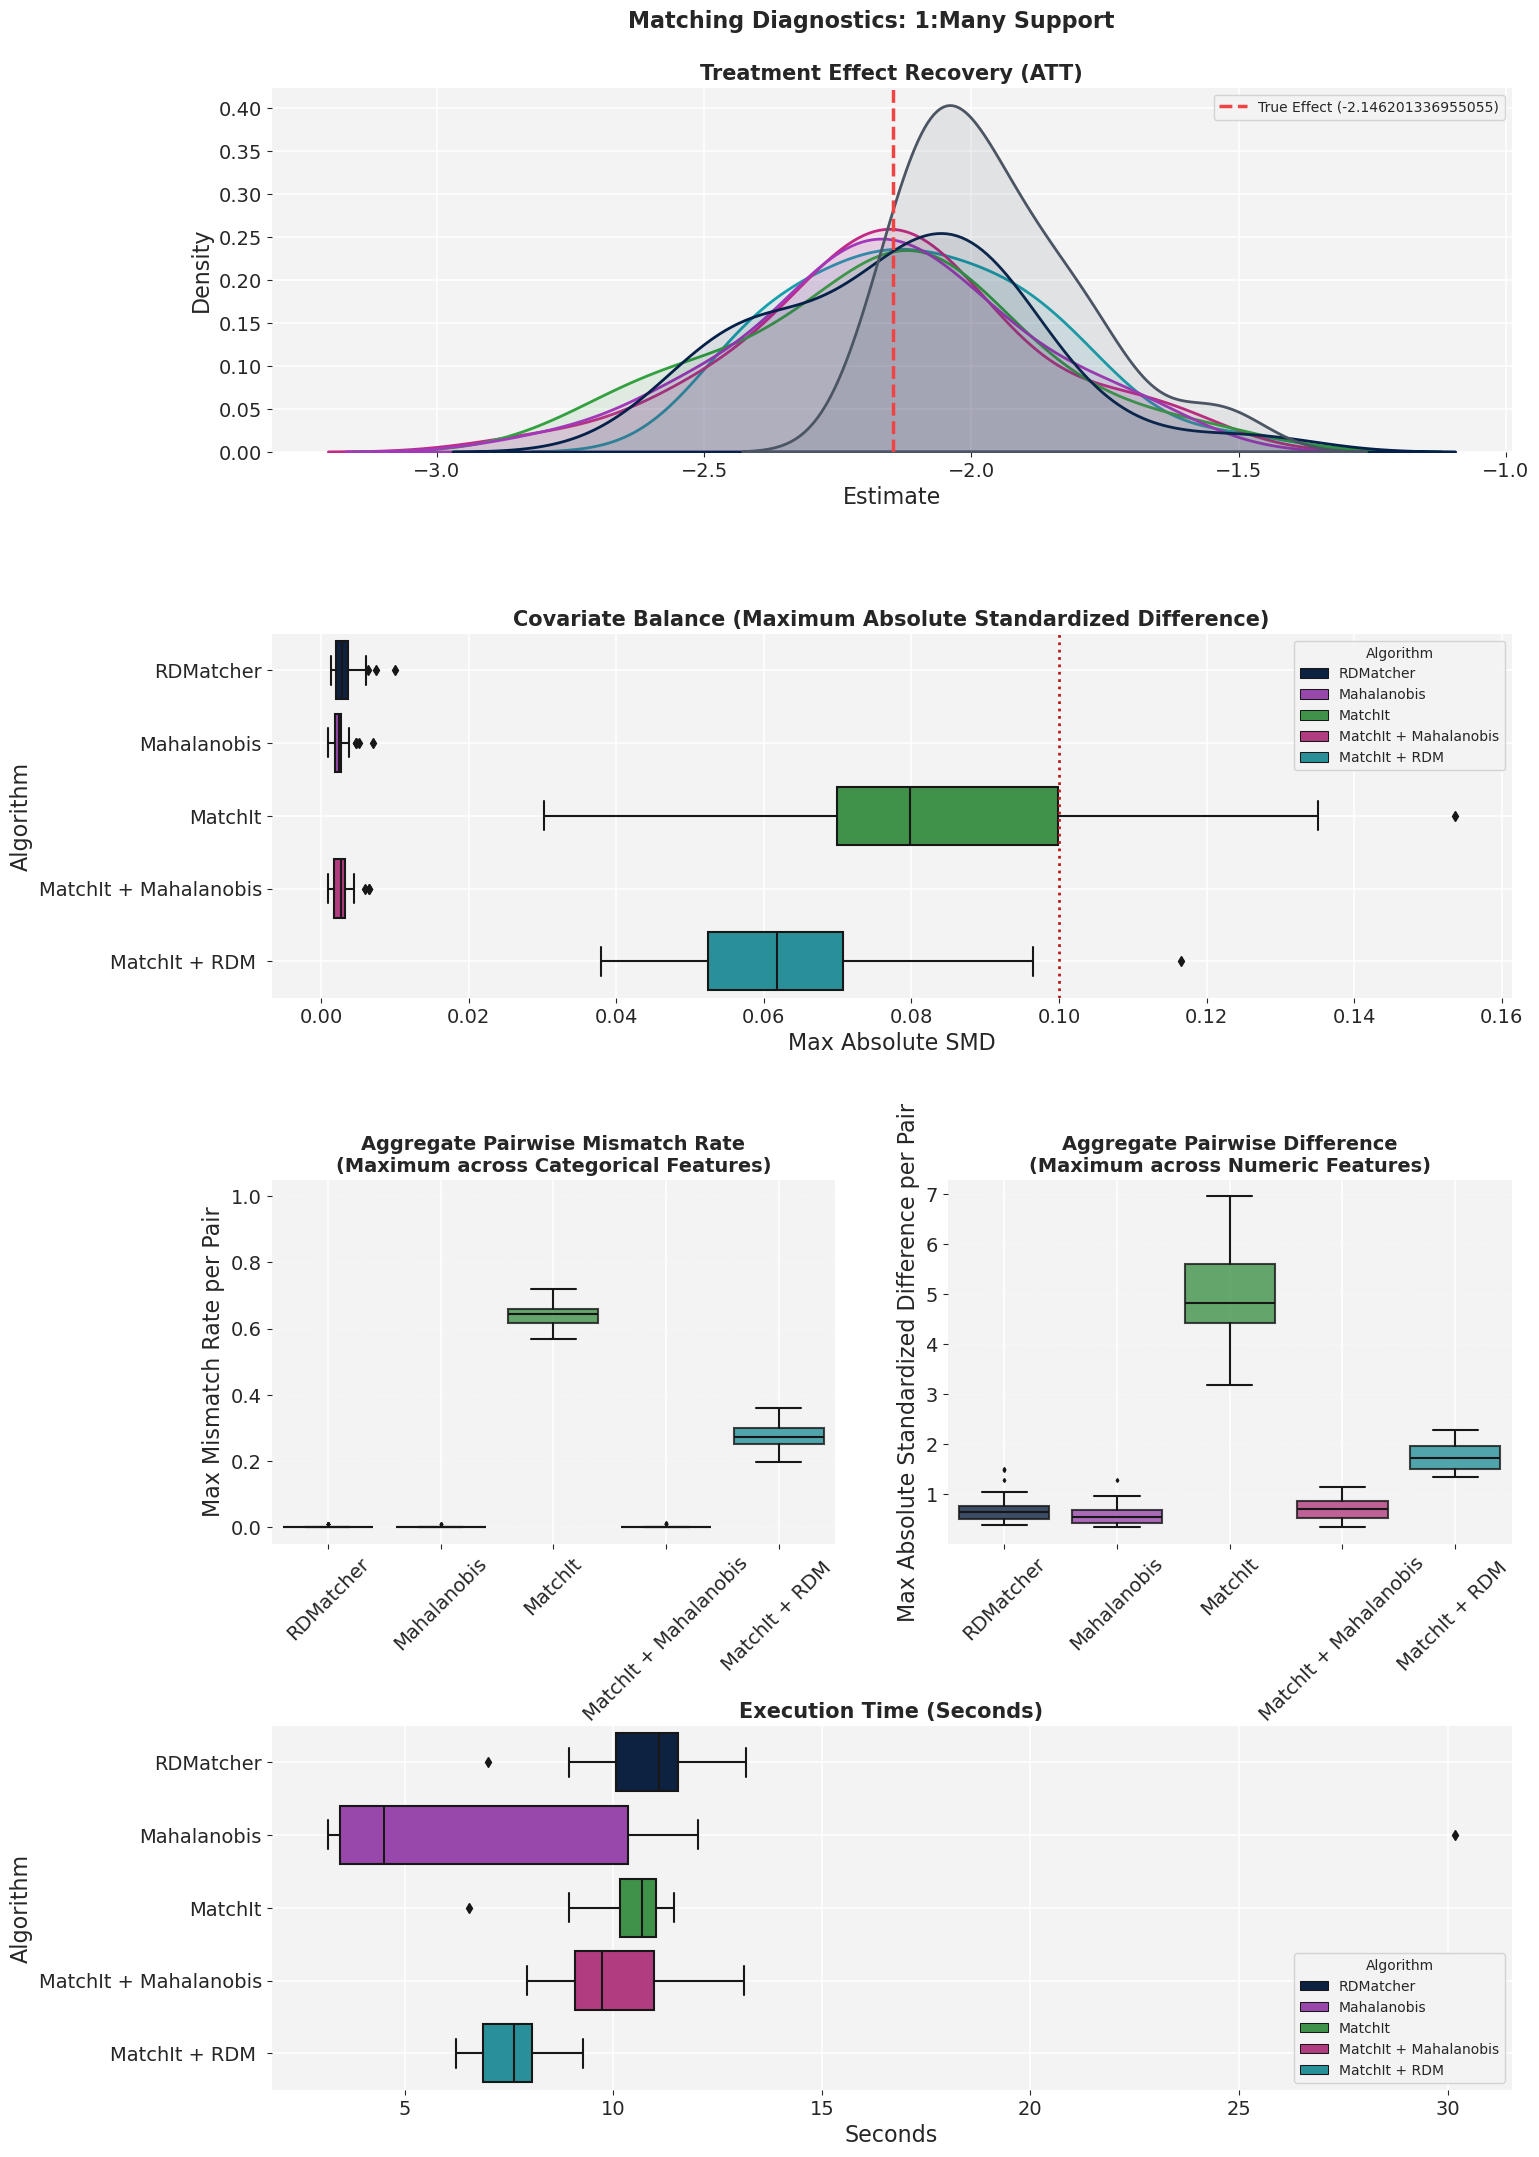

[['Crude Unmatched', '-1.955', '0.191', '0.252', 'N/A', 'N/A', '100.0%'],
 ['RDMatcher', '-2.137', '0.009', '0.246', '0.003', '10.810s', '100.0%'],
 ['Mahalanobis', '-2.162', '-0.015', '0.257', '0.003', '7.425s', '100.0%'],
 ['MatchIt', '-2.170', '-0.024', '0.276', '0.086', '10.469s', '100.0%'],
 ['MatchIt + Mahalanobis',
  '-2.155',
  '-0.009',
  '0.261',
  '0.003',
  '10.132s',
  '100.0%'],
 ['MatchIt + RDM ', '-2.100', '0.046', '0.236', '0.064', '7.525s', '96.8%']]

In [40]:

# Define your mapping
research_config = {
    # 'crude': {'name': 'Unadjusted', 'color': "#878D96"},
    'RDM':   {'name': 'RDMatcher', 'color': '#052049'},
    # 'cem':   {'name': 'CEM', 'color': "#6C62D0"},
    'Mahalanobis':   {'name': 'Mahalanobis', 'color': "#A238BA"},
    'MatchIt':   {'name': 'MatchIt', 'color': "#32A03E"},
    # 'psm':   {'name': 'PsmPy', 'color': "#C42882"},
    'Hybrid_Maha_MatchIt':   {'name': 'MatchIt + Mahalanobis', 'color': "#C42882"},
    'Hybrid_RDM_MatchIt':   {'name': 'MatchIt + RDM ', 'color': "#16A0AC"}
}

save_path = None # 'figs/one_to_many_NEW.png'


plot_simulation_advanced(
    results_df, 
    true_effect=results_df['true_att'].iloc[0], 
    algo_config=research_config, 
    save_path=save_path, 
    title_prefix='1:Many'
)

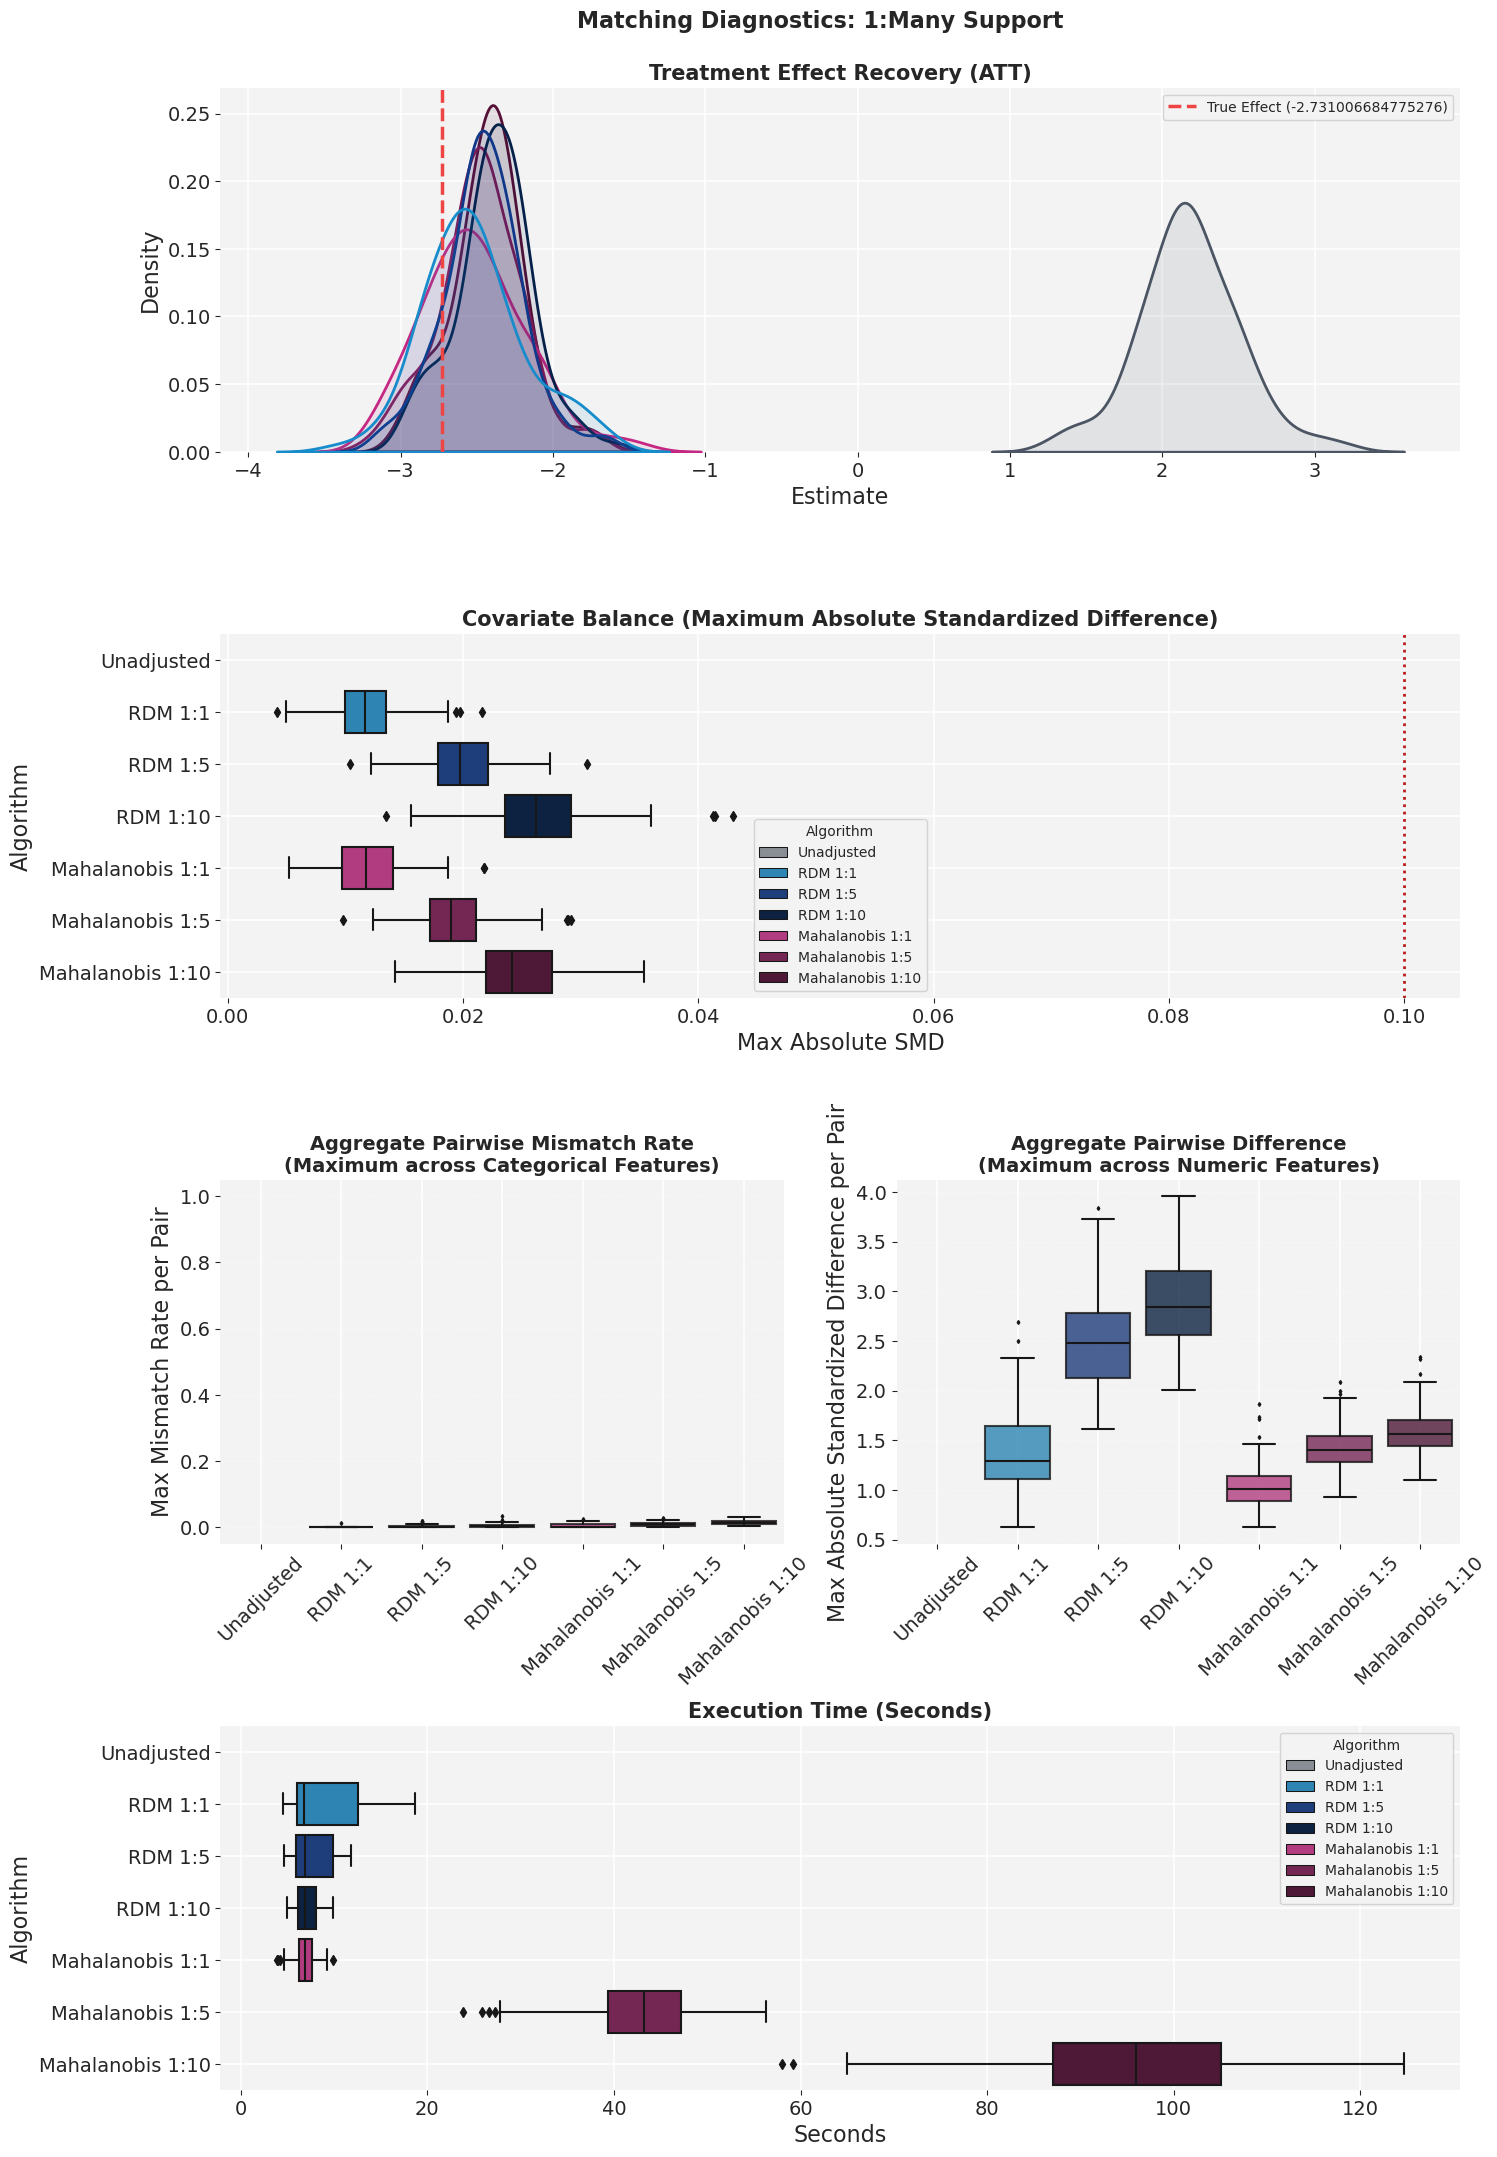

[['Crude Unmatched', '2.175', '4.906', '4.917', 'N/A', 'N/A', '100.0%'],
 ['RDM 1:1', '-2.518', '0.213', '0.399', '0.012', '9.165s', '100.0%'],
 ['RDM 1:5', '-2.459', '0.272', '0.378', '0.020', '7.618s', '100.0%'],
 ['RDM 1:10', '-2.387', '0.344', '0.428', '0.026', '7.111s', '100.0%'],
 ['Mahalanobis 1:1', '-2.516', '0.215', '0.404', '0.012', '6.822s', '100.0%'],
 ['Mahalanobis 1:5', '-2.480', '0.251', '0.372', '0.019', '42.418s', '100.0%'],
 ['Mahalanobis 1:10',
  '-2.429',
  '0.302',
  '0.391',
  '0.025',
  '95.519s',
  '100.0%']]

In [71]:

# Define your mapping
# research_config = {
#     # 'crude': {'name': 'Unadjusted', 'color': "#878D96"},
#     'RDM':   {'name': 'RDMatcher', 'color': '#052049'},
#     # 'cem':   {'name': 'CEM', 'color': "#6C62D0"},
#     'Mahalanobis':   {'name': 'Mahalanobis', 'color': "#A238BA"},
#     'MatchIt':   {'name': 'MatchIt', 'color': "#32A03E"},
#     # 'psm':   {'name': 'PsmPy', 'color': "#C42882"},
#     'Hybrid_Maha_MatchIt':   {'name': 'MatchIt + Mahalanobis', 'color': "#C42882"},
#     'Hybrid_RDM_MatchIt':   {'name': 'MatchIt + RDM ', 'color': "#16A0AC"}
# }

save_path = None #'figs/causal_low_new_sim.png'


plot_simulation_advanced(
    results_df, 
    true_effect=results_df['true_att'].iloc[0], 
    algo_config=research_config, 
    save_path=None, 
    title_prefix='1:Many'
)

In [60]:
1

1

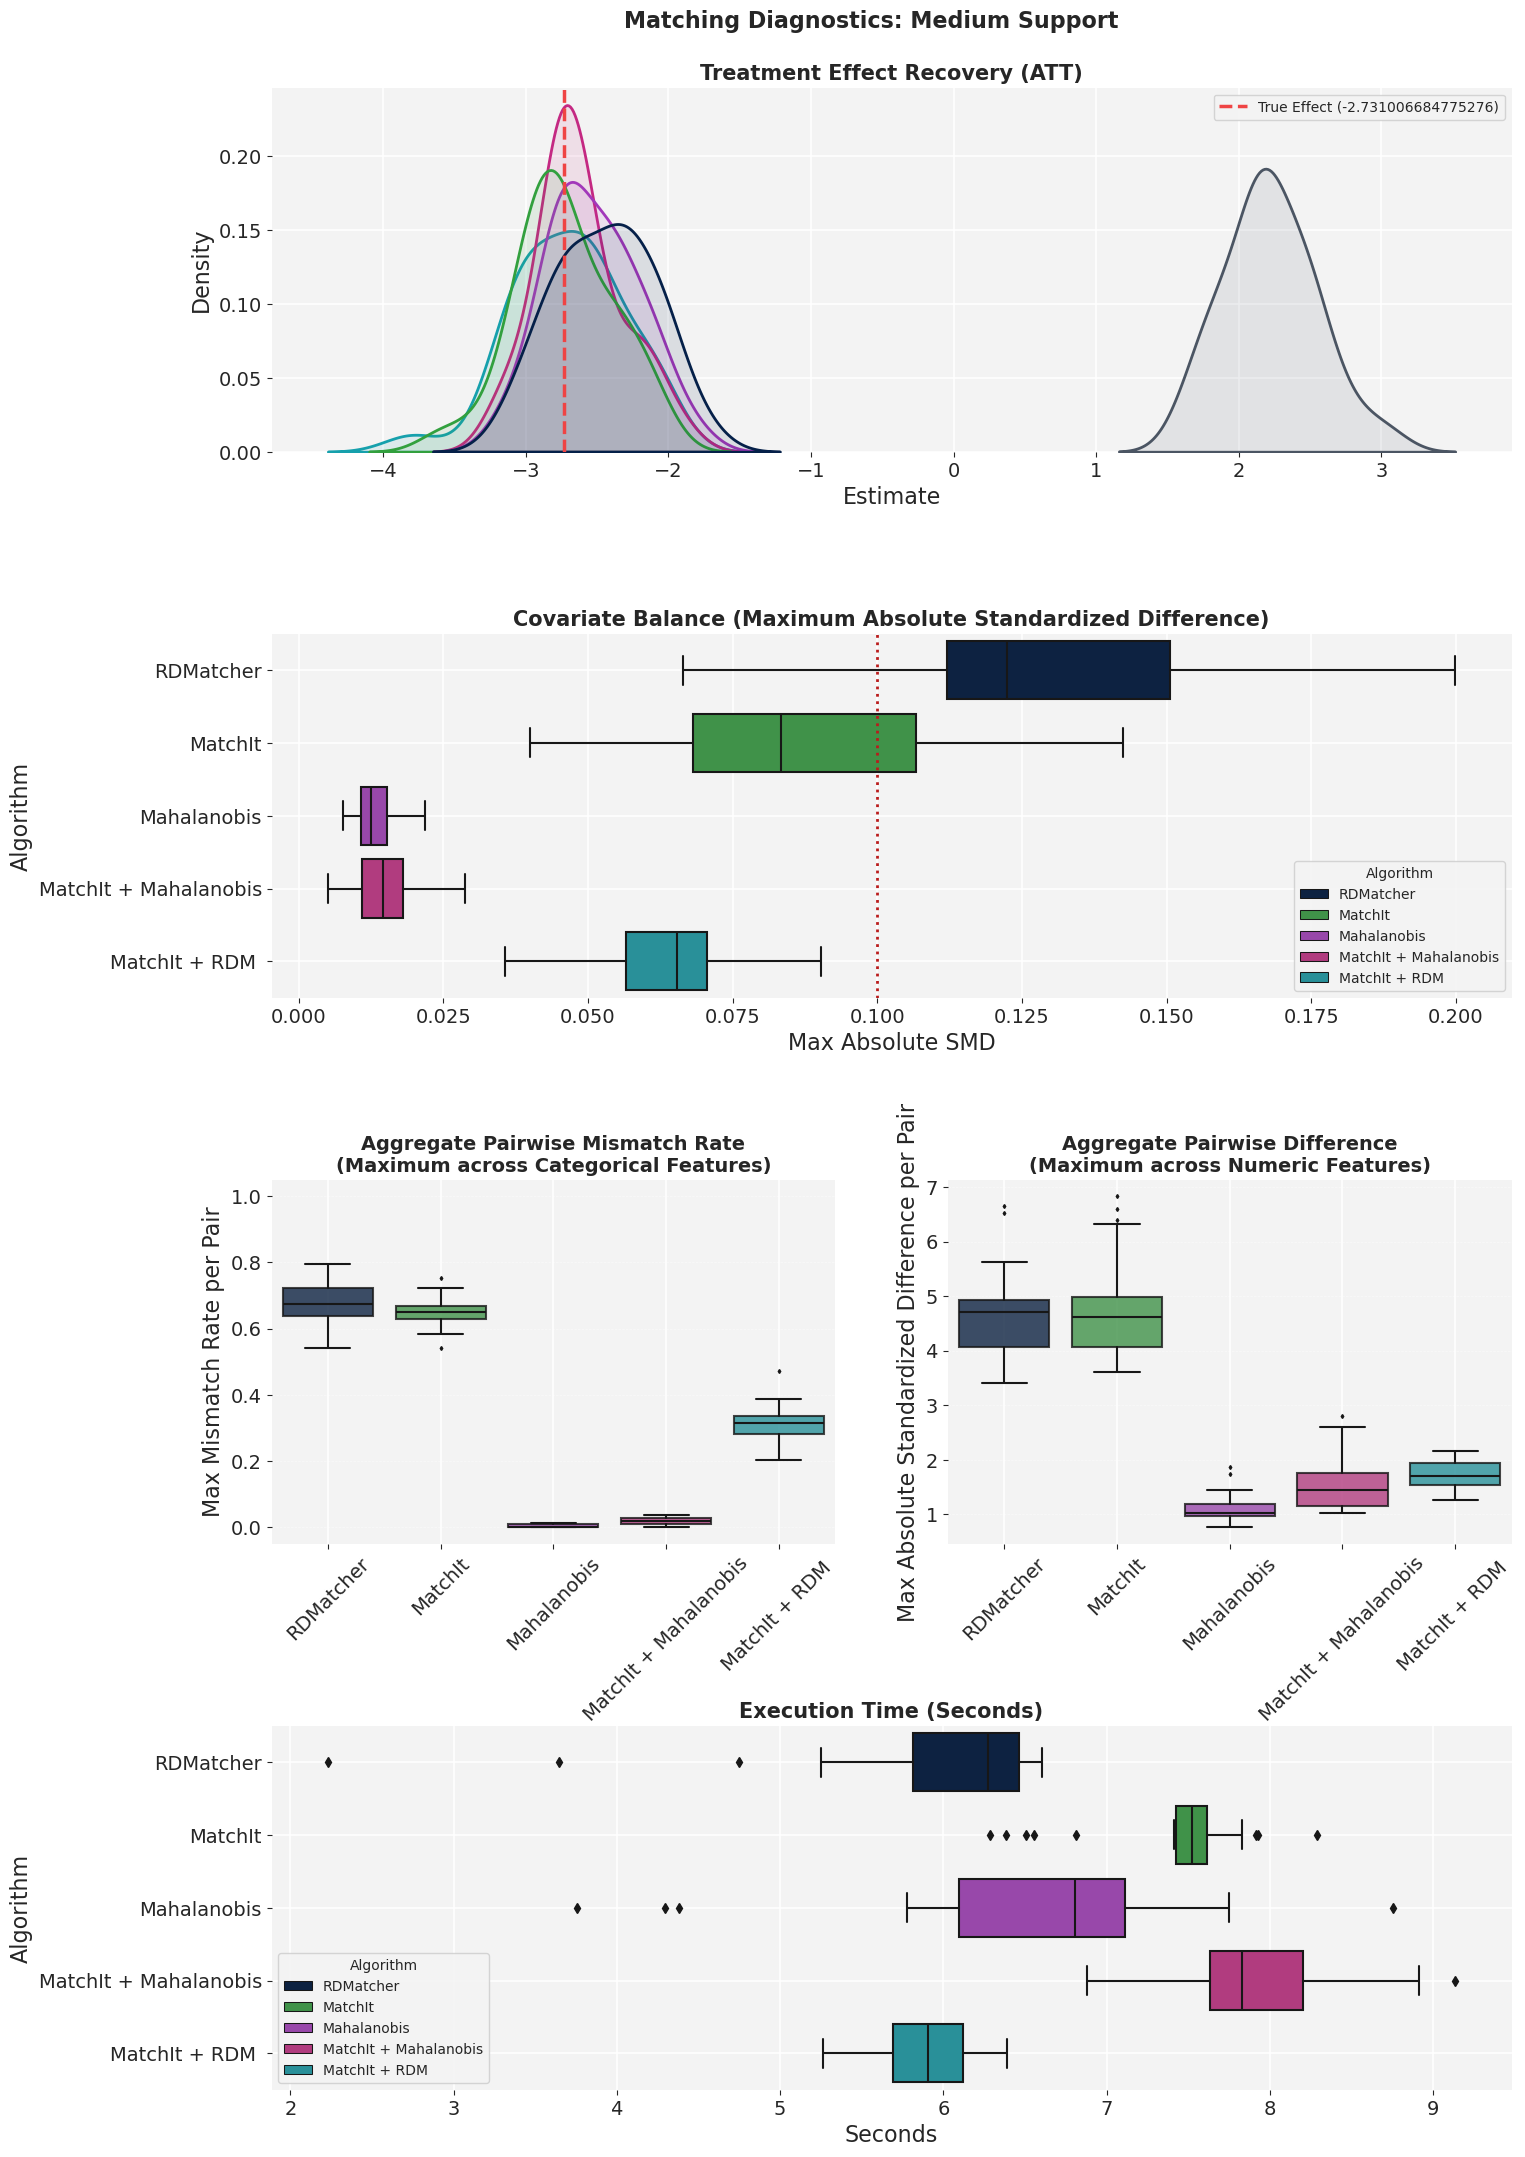

[['Crude Unmatched', '2.221', '4.952', '4.962', 'N/A', 'N/A', '100.0%'],
 ['RDMatcher', '-2.450', '0.281', '0.442', '0.131', '5.954s', '99.9%'],
 ['MatchIt', '-2.734', '-0.003', '0.337', '0.087', '7.428s', '99.9%'],
 ['Mahalanobis', '-2.534', '0.197', '0.370', '0.013', '6.518s', '100.0%'],
 ['MatchIt + Mahalanobis',
  '-2.628',
  '0.103',
  '0.313',
  '0.015',
  '7.887s',
  '99.9%'],
 ['MatchIt + RDM ', '-2.710', '0.021', '0.386', '0.063', '5.908s', '96.4%']]

In [31]:
# Define your mapping
research_config = {
    # 'crude': {'name': 'Unadjusted', 'color': "#878D96"},
    'RDM':   {'name': 'RDMatcher', 'color': '#052049'},
    'MatchIt':   {'name': 'MatchIt', 'color': "#32A03E"},
    # 'cem':   {'name': 'CEM', 'color': "#6C62D0"},
    'Mahalanobis':   {'name': 'Mahalanobis', 'color': "#A238BA"},
    # 'psm':   {'name': 'PsmPy', 'color': "#C42882"},
    'Hybrid_Maha_MatchIt':   {'name': 'MatchIt + Mahalanobis', 'color': "#C42882"},
    'Hybrid_RDM_MatchIt':   {'name': 'MatchIt + RDM ', 'color': "#16A0AC"}
}

save_path = None #'figs/causal_med_plus_2.png'


plot_simulation_advanced(
    results_df, 
    true_effect=results_df['true_att'].iloc[0], 
    algo_config=research_config, 
    save_path=None, 
    title_prefix='Medium'
)

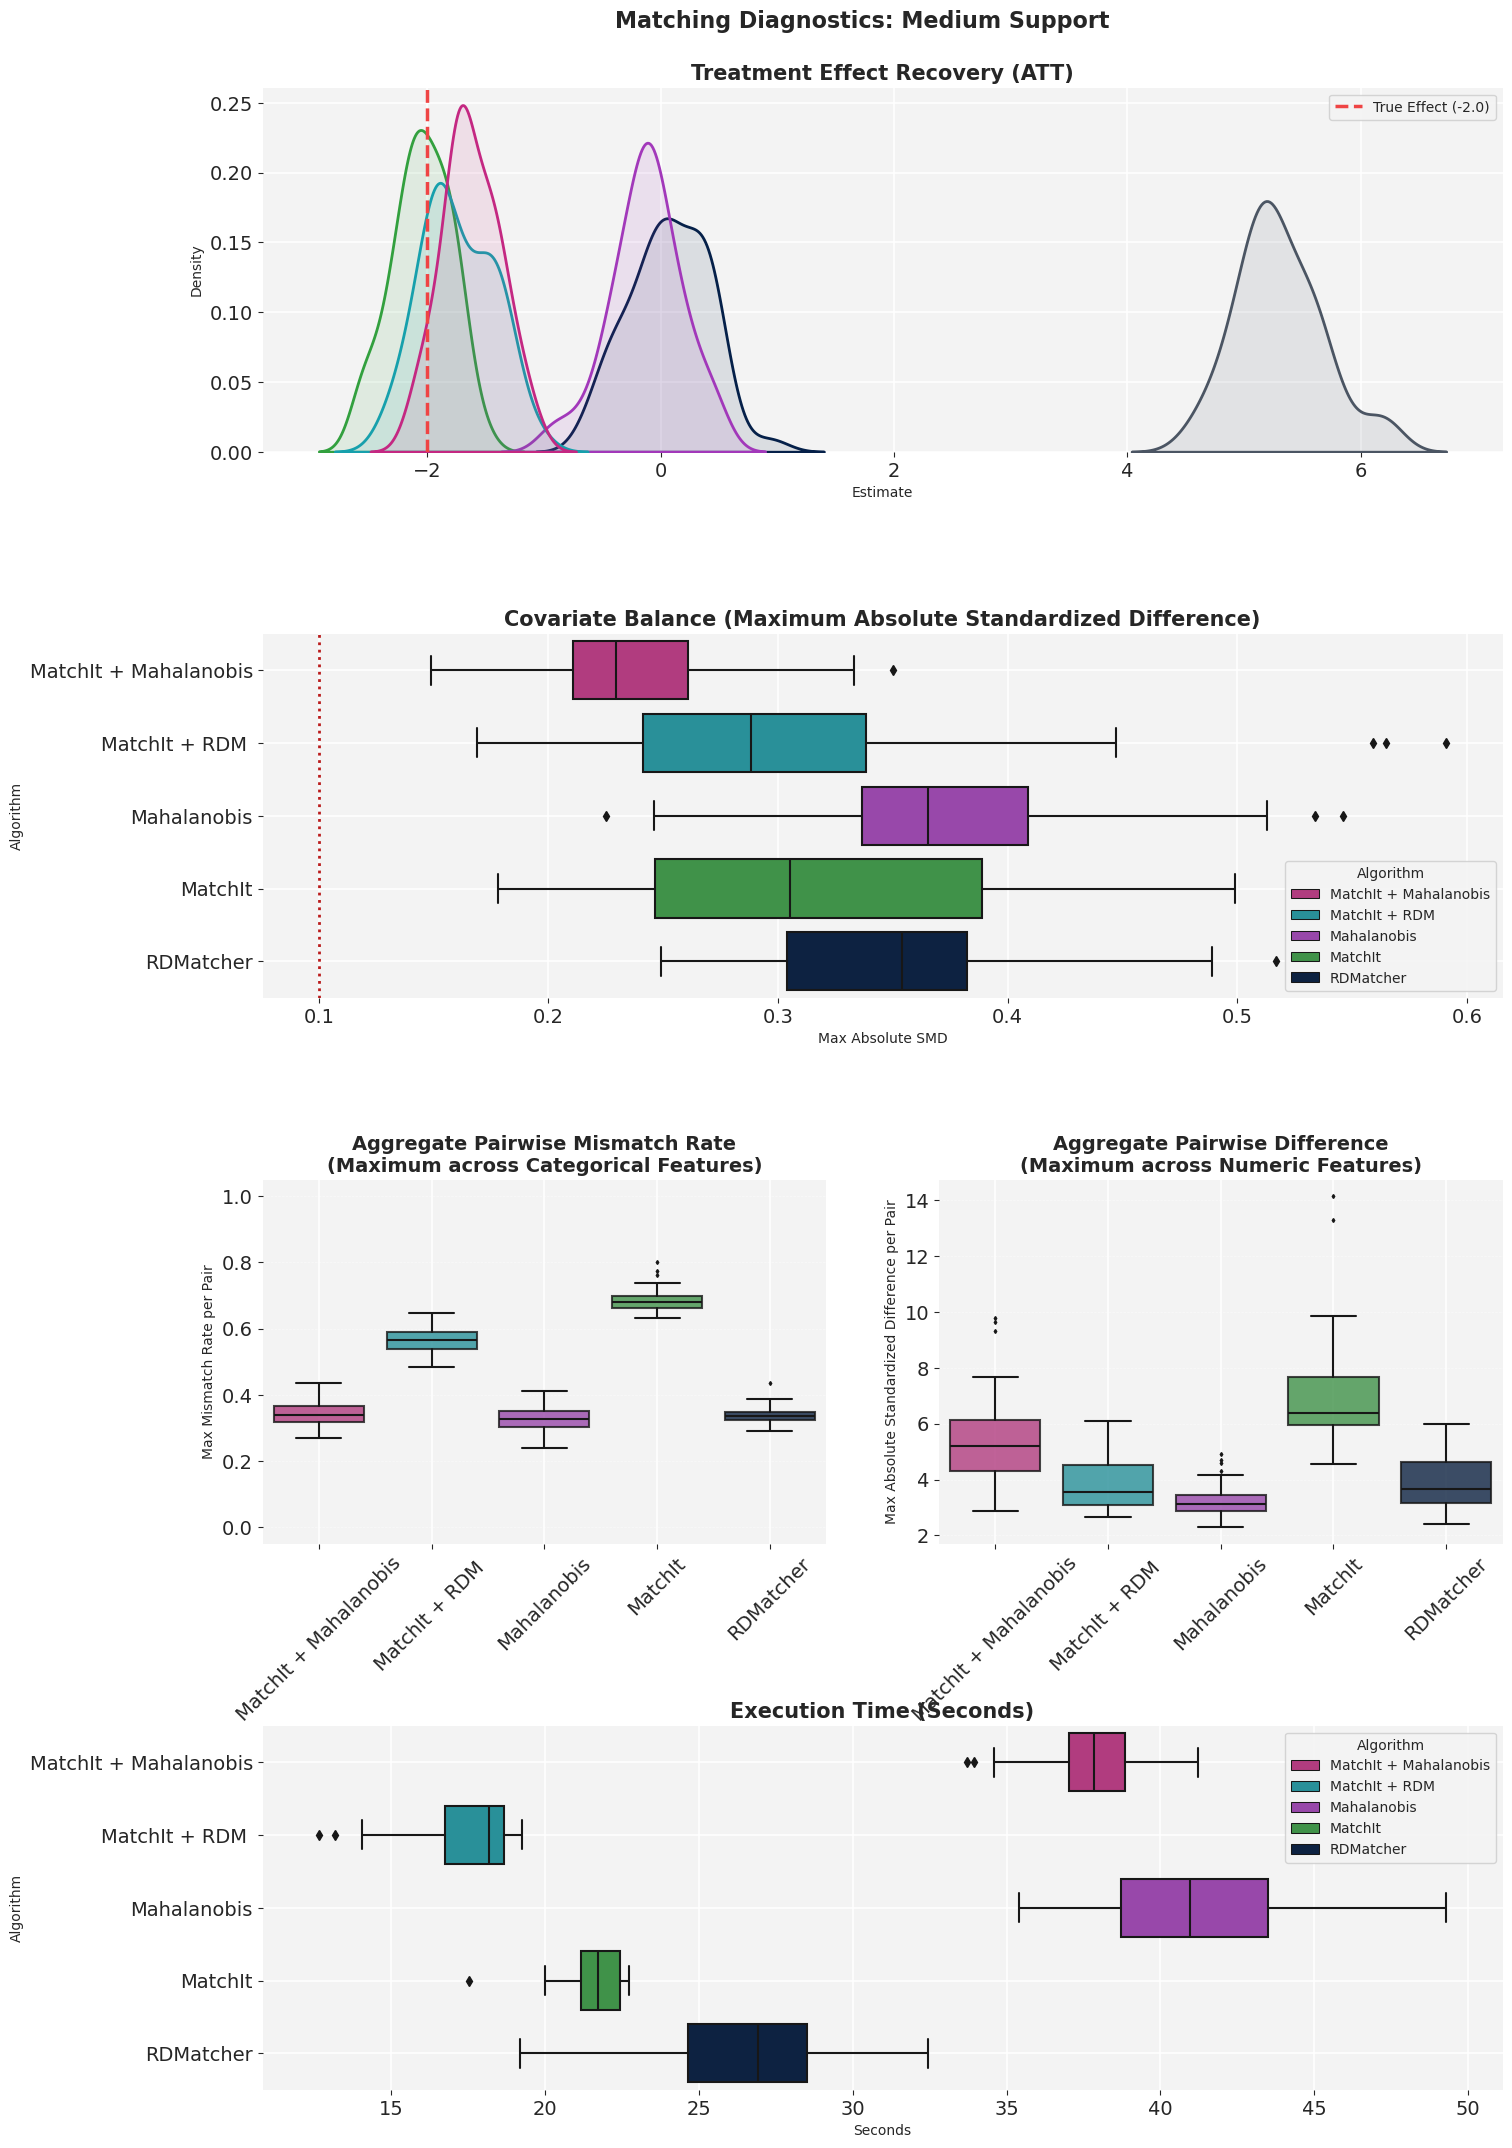

[['Crude Unmatched', '5.302', '7.302', '7.311', 'N/A', 'N/A', '100.0%'],
 ['RDMatcher', '0.070', '2.070', '2.097', '0.352', '26.606s', '99.8%'],
 ['MatchIt', '-2.049', '-0.049', '0.256', '0.320', '21.651s', '79.4%'],
 ['Mahalanobis', '-0.126', '1.874', '1.898', '0.375', '41.287s', '100.0%'],
 ['MatchIt + Mahalanobis',
  '-1.624',
  '0.376',
  '0.449',
  '0.237',
  '37.814s',
  '79.5%'],
 ['MatchIt + RDM ', '-1.740', '0.260', '0.402', '0.305', '17.534s', '76.8%']]

In [61]:
# Define your mapping
research_config = {
    # 'crude': {'name': 'Unadjusted', 'color': "#878D96"},
    'RDM':   {'name': 'RDMatcher', 'color': '#052049'},
    'MatchIt':   {'name': 'MatchIt', 'color': "#32A03E"},
    # 'cem':   {'name': 'CEM', 'color': "#6C62D0"},
    'Mahalanobis':   {'name': 'Mahalanobis', 'color': "#A238BA"},
    # 'psm':   {'name': 'PsmPy', 'color': "#C42882"},
    'Hybrid_Maha_MatchIt':   {'name': 'MatchIt + Mahalanobis', 'color': "#C42882"},
    'Hybrid_RDM_MatchIt':   {'name': 'MatchIt + RDM ', 'color': "#16A0AC"}
}

save_path = None #'figs/causal_med_plus_2.png'


plot_simulation_advanced(
    tmp_coef10_thr0_15, 
    true_effect=tmp_coef10_thr0_15['true_att'].iloc[0], 
    algo_config=research_config, 
    save_path=None, 
    title_prefix='Medium'
)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def set_r_style():
    plt.rcParams.update({
        'axes.labelsize': 16,   # Axis title font size
        'xtick.labelsize': 14,  # X-axis tick font size
        'ytick.labelsize': 14   # Y-axis tick font size
    })
    
    sns.set_style("darkgrid", {
        "axes.facecolor": "#F3F3F3",      
        "grid.color": "white",            
        "axes.edgecolor": "none",         
        "xtick.bottom": True,
        "ytick.left": True
    })

def plot_simulation_advanced(results_df, true_effect, algo_config, save_path=None, title_prefix='Medium'):
    """
    Visual comparison of causal algorithms with ATT, Balance (SMD & Pairwise), and Execution Time.
    Aggregates pairwise metrics across features to prevent visualization clutter.
    Isolates Crude Unmatched estimates to the ATT distribution plot and metrics table.
    """
    set_r_style()

    def calculate_mas(smd_table):
        if smd_table is None or not isinstance(smd_table, pd.DataFrame) or smd_table.empty:
            return np.nan
        return smd_table['SMD'].abs().mean()

    # 1. Dynamic Data Prep
    results_df['mas'] = results_df['smd'].apply(calculate_mas)
    
    method_name_map = {k: v['name'] for k, v in algo_config.items()}
    color_palette = {v['name']: v['color'] for k, v in algo_config.items()}
    
    # Establish explicit ordering based on dictionary keys
    algo_order = list(method_name_map.values())
    kde_order = ['Crude Unmatched'] + algo_order
    
    plot_df = results_df.copy()
    plot_df['Algorithm'] = plot_df['method'].map(method_name_map)
    plot_df = plot_df.dropna(subset=['Algorithm'])
    
    parsed_pairwise_data = []
    
    for idx, row in plot_df.iterrows():
        algo_name = row['Algorithm']
        
        # Numeric (MaxPD) - Aggregate across features for this iteration
        if isinstance(row['num'], dict):
            num_vals = [val for key, val in row['num'].items() if key.endswith('_maxpd')]
            if num_vals:
                parsed_pairwise_data.append({
                    'Method': algo_name, 
                    'Value': np.max(num_vals), 
                    'Metric': 'MaxPD'
                })
                    
        # Categorical (PMR) - Aggregate across features for this iteration
        if isinstance(row['cat'], dict):
            cat_vals = [val for key, val in row['cat'].items() if key.endswith('_pmr')]
            if cat_vals:
                parsed_pairwise_data.append({
                    'Method': algo_name, 
                    'Value': np.max(cat_vals), 
                    'Metric': 'PMR'
                })

    pairwise_df = pd.DataFrame(parsed_pairwise_data)
    if pairwise_df.empty:
        print("No pairwise metrics found. Skipping pairwise plots.")

    # Extract Crude Data (one per unique seed)
    iter_col = 'seed' if 'seed' in results_df.columns else 'iteration'
    crude_series = results_df.drop_duplicates(subset=[iter_col])['crude_att'].dropna()
    
    # Create a combined dataframe specifically for the ATT KDE plot
    att_plot_df = plot_df[['att', 'Algorithm']].dropna()
    crude_plot_df = pd.DataFrame({'att': crude_series, 'Algorithm': 'Crude Unmatched'})
    combined_att_df = pd.concat([att_plot_df, crude_plot_df], ignore_index=True)
    
    # Extend color palette for the Crude distribution
    kde_palette = color_palette.copy()
    kde_palette['Crude Unmatched'] = '#4b5563' # Slate Gray

    # 2. Figure Setup
    fig = plt.figure(figsize=(16, 26))
    gs = fig.add_gridspec(4, 2, hspace=0.5, wspace=0.2)
    
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, :])
    ax3a = fig.add_subplot(gs[2, 0])
    ax3b = fig.add_subplot(gs[2, 1])
    ax4 = fig.add_subplot(gs[3, :])

    all_axes = [ax1, ax2, ax3a, ax3b, ax4]

    # --- ROW 1: ATT DISTRIBUTIONS (Includes Crude) ---
    # Applied hue_order
    sns.kdeplot(data=combined_att_df, x='att', hue='Algorithm', 
                fill=True, ax=ax1, palette=kde_palette, alpha=0.1, linewidth=2,
                hue_order=kde_order)
    ax1.axvline(true_effect, color='#ef4444', linestyle='--', linewidth=2.5, label=f'True Effect ({true_effect})', zorder=10)
    ax1.set_title('Treatment Effect Recovery (ATT)', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Estimate')
    if ax1.get_legend(): ax1.legend()

    # --- ROW 2: COVARIATE BALANCE (MAS) ---
    # Applied order and hue_order
    sns.boxplot(data=plot_df.dropna(subset=['mas']), x='mas', y='Algorithm', hue='Algorithm', 
                palette=color_palette, ax=ax2, boxprops=dict(alpha=1.0), dodge=False,
                order=algo_order, hue_order=algo_order)
    ax2.axvline(0.1, color='#b91c1c', linestyle=':', linewidth=2, label='Threshold (0.1)')
    ax2.set_title('Covariate Balance (Maximum Absolute Standardized Difference)', fontsize=15, fontweight='bold')
    ax2.set_xlabel('Max Absolute SMD')

    # --- ROW 3: GRANULAR PAIRWISE METRICS (AGGREGATED) ---
    if not pairwise_df.empty:
        df_cat = pairwise_df[pairwise_df['Metric'] == 'PMR']
        df_num = pairwise_df[pairwise_df['Metric'] == 'MaxPD']

        # 3A (Left): Categorical (PMR)
        # Applied order and hue_order
        if not df_cat.empty:
            sns.boxplot(data=df_cat, x='Method', y='Value', hue='Method', palette=color_palette, ax=ax3a, 
                        boxprops=dict(alpha=0.8), fliersize=2, dodge=False,
                        order=algo_order, hue_order=algo_order)
            ax3a.set_title('Aggregate Pairwise Mismatch Rate\n(Maximum across Categorical Features)', fontsize=14, fontweight='bold')
            ax3a.set_ylabel('Max Mismatch Rate per Pair')
            ax3a.set_xlabel('')
            ax3a.set_ylim(-0.05, 1.05) 
            ax3a.tick_params(axis='x', rotation=45)
            if ax3a.get_legend(): ax3a.get_legend().remove()

        # 3B (Right): Numeric (MaxPD)
        # Applied order and hue_order
        if not df_num.empty:
            sns.boxplot(data=df_num, x='Method', y='Value', hue='Method', palette=color_palette, ax=ax3b, 
                        boxprops=dict(alpha=0.8), fliersize=2, dodge=False,
                        order=algo_order, hue_order=algo_order)
            ax3b.set_title('Aggregate Pairwise Difference\n(Maximum across Numeric Features)', fontsize=14, fontweight='bold')
            ax3b.set_ylabel('Max Absolute Standardized Difference per Pair')
            ax3b.set_xlabel('')
            ax3b.tick_params(axis='x', rotation=45)
            if ax3b.get_legend(): ax3b.get_legend().remove()

    # --- ROW 4: COMPUTATIONAL TIME ---
    # Applied order and hue_order
    sns.boxplot(data=plot_df.dropna(subset=['time']), x='time', y='Algorithm', hue='Algorithm', 
                palette=color_palette, ax=ax4, boxprops=dict(alpha=1.0), dodge=False,
                order=algo_order, hue_order=algo_order)
    ax4.set_title('Execution Time (Seconds)', fontsize=15, fontweight='bold')
    ax4.set_xlabel('Seconds')

    # 3. Table Construction
    metrics = []
    
    # Prepend Crude metrics to the table
    if not crude_series.empty:
        crude_bias = crude_series.mean() - true_effect
        crude_rmse = np.sqrt(((crude_series - true_effect)**2).mean())
        metrics.append([
            "Crude Unmatched", 
            f"{crude_series.mean():.3f}", 
            f"{crude_bias:.3f}", 
            f"{crude_rmse:.3f}", 
            "N/A", 
            "N/A", 
            "100.0%"
        ])

    for raw_method, config in algo_config.items():
        algo_name = config['name']
        group = plot_df[plot_df['method'] == raw_method]
        
        if group.empty:
            continue
            
        est = group['att'].dropna()
        if not est.empty:
            bias = est.mean() - true_effect
            rmse = np.sqrt(((est - true_effect)**2).mean())
        else:
            bias, rmse = np.nan, np.nan
            
        m_mas = group['mas'].dropna().mean()
        m_time = group['time'].dropna().mean()
        m_retention = group['retention'].dropna().mean()
        
        metrics.append([
            algo_name, 
            f"{est.mean():.3f}" if not est.empty else "N/A", 
            f"{bias:.3f}" if not np.isnan(bias) else "N/A", 
            f"{rmse:.3f}" if not np.isnan(rmse) else "N/A", 
            f"{m_mas:.3f}" if not np.isnan(m_mas) else "N/A",
            f"{m_time:.3f}s" if not np.isnan(m_time) else "N/A",
            f"{m_retention:.1%}" if not np.isnan(m_retention) else "N/A"
        ])

    for ax in all_axes:
        sns.despine(ax=ax, left=True, bottom=True)
        ax.grid(True, which='major', linestyle='-', linewidth=1.2)
        if ax in [ax3a, ax3b]:
            ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.suptitle(f"Matching Diagnostics: {title_prefix} Support", fontsize=16, fontweight='bold', y=0.91)
    
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=600)
        
    plt.show()
    
    return metrics

### Plot Distributions

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

def set_r_style():
    sns.set_style("darkgrid", {
        "axes.facecolor": "#F3F3F3",      
        "grid.color": "white",            
        "axes.edgecolor": "none",         
        "xtick.bottom": True,
        "ytick.left": True
    })

def format_feature_name(col, label_map):
    if not label_map:
        return col
    # 1. Exact match for continuous or unencoded variables
    if col in label_map:
        return label_map[col]
    
    # 2. Dynamic match for one-hot encoded dummy variables
    for base_key, readable_name in label_map.items():
        if col.startswith(f"{base_key}_"):
            category_val = col.replace(f"{base_key}_", "")
            return f"{readable_name}: {category_val}"
            
    return col

def plot_imbalanced_dgp_diagnostics(df_obs, features_numeric, features_categorical, 
                                    treatment_node, outcome_node, label_map=None, 
                                    title_prefix='Medium', save_path=None):
    """
    Robust 2-panel causal diagnostic for highly imbalanced simulation data.
    Panel 1: Propensity Score Overlap (using a diagnostic downsample).
    Panel 2: Empirical Confounding Strength (calculated on full encoded data).
    """
    set_r_style()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plt.subplots_adjust(wspace=0.3)
    
    # 1. Pre-process and Encode Categoricals
    df_encoded = pd.get_dummies(df_obs, columns=features_categorical, drop_first=True, dtype=int)
    encoded_covariates = features_numeric + [col for col in df_encoded.columns if col.startswith(tuple([f"{c}_" for c in features_categorical]))]

    # --- PANEL 1: Diagnostic Propensity Score Overlap ---
    # Downsample controls strictly to force the diagnostic model to map the feature space
    treated = df_encoded[df_encoded[treatment_node] == 1]
    controls = df_encoded[df_encoded[treatment_node] == 0]
    
    # Use a 1:10 ratio for the diagnostic plot
    sample_size = min(len(controls), len(treated) * 10)
    diag_controls = controls.sample(n=sample_size, random_state=42)
    df_diag = pd.concat([treated, diag_controls]).copy()

    X_diag = df_diag[encoded_covariates]
    y_diag = df_diag[treatment_node]
    
    ps_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    ps_model.fit(X_diag, y_diag)
    df_diag['diagnostic_ps'] = ps_model.predict_proba(X_diag)[:, 1]

    sns.kdeplot(data=df_diag[df_diag[treatment_node] == 1], x='diagnostic_ps', 
                fill=True, color='#052049', label='Treated (All)', ax=axes[0], linewidth=2)
    sns.kdeplot(data=df_diag[df_diag[treatment_node] == 0], x='diagnostic_ps', 
                fill=True, color='#878D96', label='Control (1:10 Sample)', ax=axes[0], linewidth=2)
    axes[0].set_title('Diagnostic Positivity (Feature Overlap)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Estimated Propensity Score (Downsampled Model)')
    axes[0].set_ylabel('Density')
    axes[0].legend(loc='upper right')

    # --- PANEL 2: Confounding Strength (SMD on FULL DATA) ---
    smd_records = []
    
    treated_df_full = df_encoded[df_encoded[treatment_node] == 1]
    control_df_full = df_encoded[df_encoded[treatment_node] == 0]
    
    for col in encoded_covariates:
        mean1 = treated_df_full[col].mean()
        mean0 = control_df_full[col].mean()
        var1 = treated_df_full[col].var()
        var0 = control_df_full[col].var()
        
        pooled_sd = np.sqrt((var1 + var0) / 2.0)
        smd = 0 if pooled_sd == 0 else np.abs((mean1 - mean0) / pooled_sd)
            
        # Apply the dynamic formatting
        # base_name = format_feature_name(col, label_map)
        base_name = col
        
        smd_records.append({'Feature': base_name, 'Absolute SMD': smd})
        
    df_smd = pd.DataFrame(smd_records).sort_values(by='Absolute SMD', ascending=False)

    sns.barplot(data=df_smd, y='Feature', x='Absolute SMD', ax=axes[1], color='#506380')
    axes[1].set_title('Empirical Confounding Strength', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Absolute Standardized Mean Difference (SMD)')
    axes[1].axvline(0.1, color='black', linestyle='--', alpha=0.5) # Reference line for imbalance
    axes[1].set_ylabel('')
    axes[1].set_xlim(0, 2)

    # Clean up aesthetics
    for ax in axes:
        sns.despine(ax=ax, left=True, bottom=True)
        ax.grid(True, axis='x', linestyle='-', linewidth=1.2)
        ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.suptitle(f"Data Generation: {title_prefix} Support", fontsize=16, fontweight='bold', y=1)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=600)
    
    plt.show()

/mnt/nfs/CX900004_DS31/.conda/envs/deid-env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


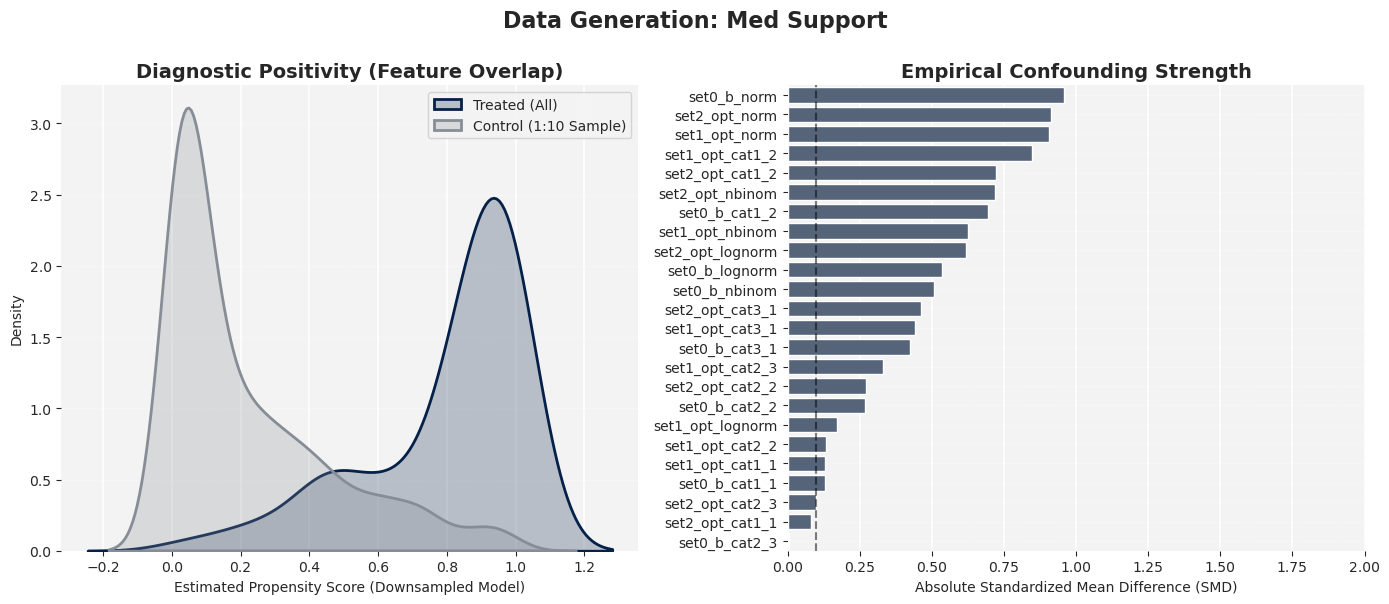

In [172]:
df_complete, true_ate, true_att, features_numeric, features_categorical, features_exclude, features_interaction = generate_cohort(
    n_patients=1_000_000,
    full_dag_spec=cohort_config,
    treatment_node="exposure_status",
    outcome_node="outcome",
    include_sets=[0, 1, 2],
    seed=1,
    target_treated_count=100
)

plot_imbalanced_dgp_diagnostics(
    df_complete, 
    features_numeric, 
    features_categorical, 
    treatment_node='exposure_status', 
    outcome_node='outcome', 
    # label_map=label_map, 
    title_prefix='Med',
    save_path=None
)